# Federated Learning Sensitivity Analysis with Knowledge Distillation

This notebook presents a comprehensive analysis of **Federated Learning (FL)** under varying client configurations, with a focus on **client count sensitivity** and **data heterogeneity (IID vs non-IID)** for a multi-label classification task.

In addition to standard FL baselines, we introduce and evaluate **Knowledge Distillation (KD)** strategies designed to improve robustness under non-IID settings.

### Core Components

- **Federated Training**  
  Clients train models locally and synchronize via weighted aggregation (FedAvg). Variants such as **FedProx** are included to mitigate client drift.

- **Client Sensitivity Analysis**  
  We systematically vary the number of clients (e.g., 2 → 10+) to study how increasing data fragmentation impacts performance under:
  - IID splits
  - Non-IID splits (label skew + size imbalance)

- **Knowledge Distillation (KD) Methods**
  - **Option 1 (Local KD / Drift Control):**  
    Each client distills knowledge from a frozen copy of the global model during local training.
  - **Option 3 (Local Teacher → Global Student):**  
    Each client maintains a stronger local teacher model and distills its knowledge into a shared global student.

- **Evaluation Metrics**  
  Models are evaluated using:
  - Macro / Micro F1-score
  - AUC and PR-AUC
  - Loss and prediction statistics

### Goal

The objective is to understand how **federated optimization behaves under increasing client fragmentation and heterogeneity**, and whether **knowledge distillation can improve stability and generalization** in these settings.

---

## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import csv
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config
import itertools
from typing import Optional

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Output directory structure for KD notebook

KD_HISTORY_DIR = os.path.join("..", "History", "KD")
os.makedirs(KD_HISTORY_DIR, exist_ok=True)

def ensure_dir(path: str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

KD_DIRS = {
    "baseline_fl_sensitivity": ensure_dir(os.path.join(KD_HISTORY_DIR, "baseline_fl_sensitivity")),
    "kd_method_sensitivity": ensure_dir(os.path.join(KD_HISTORY_DIR, "kd_method_sensitivity")),
    "opt3_phase1_tuning": ensure_dir(os.path.join(KD_HISTORY_DIR, "opt3_phase1_tuning")),
    "opt3_phase2_tuning": ensure_dir(os.path.join(KD_HISTORY_DIR, "opt3_phase2_tuning")),
    "final_opt3_sweeps": ensure_dir(os.path.join(KD_HISTORY_DIR, "final_opt3_sweeps")),
}

In [3]:
# Result file paths

BASELINE_SENS_CSV  = os.path.join(KD_DIRS["baseline_fl_sensitivity"], "baseline_sensitivity_results.csv")
BASELINE_SENS_JSON = os.path.join(KD_DIRS["baseline_fl_sensitivity"], "baseline_sensitivity_results.json")

KD_SWEEP_CSV  = os.path.join(KD_DIRS["kd_method_sensitivity"], "kd_client_sweep_results_r10_e1.csv")
KD_SWEEP_JSON = os.path.join(KD_DIRS["kd_method_sensitivity"], "kd_client_sweep_results_r10_e1.json")

PHASE1_CSV  = os.path.join(KD_DIRS["opt3_phase1_tuning"], "opt3_phase1_tuning_r10_e1.csv")
PHASE1_JSON = os.path.join(KD_DIRS["opt3_phase1_tuning"], "opt3_phase1_tuning_r10_e1.json")

PHASE2_CSV  = os.path.join(KD_DIRS["opt3_phase2_tuning"], "opt3_phase2_serverdistill_tuning_r10_e1.csv")
PHASE2_JSON = os.path.join(KD_DIRS["opt3_phase2_tuning"], "opt3_phase2_serverdistill_tuning_r10_e1.json")

FINAL_NONIID_CSV  = os.path.join(KD_DIRS["final_opt3_sweeps"], "final_opt3_noniid_sweep_r100_e3.csv")
FINAL_NONIID_JSON = os.path.join(KD_DIRS["final_opt3_sweeps"], "final_opt3_noniid_sweep_r100_e3.json")

FINAL_IID_CSV  = os.path.join(KD_DIRS["final_opt3_sweeps"], "final_opt3_iid_sweep_r100_e3.csv")
FINAL_IID_JSON = os.path.join(KD_DIRS["final_opt3_sweeps"], "final_opt3_iid_sweep_r100_e3.json")

FINAL_COMBINED_CSV = os.path.join(KD_DIRS["final_opt3_sweeps"], "final_opt3_combined_sweep_r100_e3.csv")

## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [4]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [5]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

In [6]:
def save_dict_rows_to_csv(rows: list[dict], filepath: str) -> None:
    """
    Save a list of dictionaries to a CSV file.
    """
    if not rows:
        print(f"[save_dict_rows_to_csv] No rows to save for {filepath}")
        return

    fieldnames = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved CSV: {filepath}")

def to_serializable_row(row: dict) -> dict:
    """
    Convert metric values to plain Python scalars when possible.
    """
    cleaned = {}
    for k, v in row.items():
        if isinstance(v, (np.floating, np.integer)):
            cleaned[k] = v.item()
        elif isinstance(v, torch.Tensor):
            cleaned[k] = v.item() if v.numel() == 1 else v.detach().cpu().tolist()
        else:
            cleaned[k] = v
    return cleaned

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [7]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [8]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [9]:
def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.
    Returns a NEW averaged parameter dictionary.
    """
    new_global = {}
    for key in global_model.keys():
        stacked = torch.stack(
            [client_dict[key].detach().cpu().float() for client_dict in client_state_dicts],
            dim=0
        )
        new_global[key] = torch.mean(stacked, dim=0)
    return new_global

In [10]:
# --- FedProx and SCAFFOLD Aggregation Methods ---

def FedProx(global_model_dict, client_state_dicts, mu=0.01):
    """
    FedProx aggregation (same averaging as FedAvg,
    since proximal regularization happens in local training).

    Args:
        global_model_dict (dict): Global model parameters.
        client_state_dicts (list[dict]): List of client parameter dicts.
        mu (float): Proximal term weight (applied during local updates).
    """
    return FedAvg(global_model_dict, client_state_dicts)


def Scaffold(global_model_dict, client_state_dicts, c_global, c_clients_old, c_clients_new):
    """
    SCAFFOLD server update.

    Model update:
        same aggregation as FedAvg over corrected local client models

    Global control variate update:
        c <- c + average(c_i_new - c_i_old)

    Args:
        global_model_dict (dict): Current global model state_dict.
        client_state_dicts (list[dict]): Client model state_dicts after local training.
        c_global (dict): Global control variate dict, keyed by parameter name.
        c_clients_old (list[dict]): Client control variates before this round.
        c_clients_new (list[dict]): Client control variates after this round.

    Returns:
        tuple[dict, dict]:
            - new global model state_dict
            - new global control variate dict
    """
    # Global model update is just FedAvg of the corrected local models
    new_global = FedAvg(global_model_dict, client_state_dicts)

    # Global control variate update
    new_c_global = {}
    num_clients = len(c_clients_new)

    for name in c_global.keys():
        delta_c = torch.stack(
            [c_clients_new[k][name] - c_clients_old[k][name] for k in range(num_clients)],
            dim=0
        ).mean(dim=0)

        new_c_global[name] = c_global[name] + delta_c

    return new_global, new_c_global

### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [11]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [12]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [13]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    mu: float = 0.01,                   # FedProx proximal coefficient
    global_params: dict = None,         # for FedProx / SCAFFOLD
    c_global: dict = None,              # for SCAFFOLD (parameter names only)
    c_local: dict = None,               # for SCAFFOLD (parameter names only)
    algorithm: str = "FedAvg",           # "FedAvg", "FedProx", or "SCAFFOLD"
    momentum: float = 0.0
) -> tuple[float, dict, dict]:
    """
    Perform local training for a single client.
    Supports FedAvg, FedProx, and SCAFFOLD.

    Returns:
        tuple:
            - final loss
            - cloned model state_dict after local training
            - updated local control variate dict (or original c_local / None)
    """
    model.to(device)
    model.train()

    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
    if algorithm == "SCAFFOLD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    last_loss = None

    # Count optimizer steps for SCAFFOLD local control update
    step_count = 0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            # --- FedProx proximal term ---
            if algorithm == "FedProx" and global_params is not None:
                prox_term = 0.0
                for name, w in model.named_parameters():
                    w_global = global_params[name].to(device)
                    prox_term += (w - w_global).norm(2) ** 2
                loss += (mu / 2.0) * prox_term

            optimizer.zero_grad()
            loss.backward()

            # --- SCAFFOLD gradient correction ---
            if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
                with torch.no_grad():
                    for name, w in model.named_parameters():
                        if w.grad is not None:
                            w.grad += c_global[name].to(device) - c_local[name].to(device)

            optimizer.step()
            step_count += 1
            last_loss = loss.item()

    # Safe cloned return for aggregation
    new_weights = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }

    # --- SCAFFOLD local control variate update ---
    new_c_local = c_local
    if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
        if global_params is None:
            raise ValueError("global_params must be provided for SCAFFOLD")

        if step_count == 0:
            raise ValueError("SCAFFOLD step_count is zero; train_loader appears empty")

        new_c_local = {}
        with torch.no_grad():
            for name in c_global.keys():
                w_global = global_params[name].to(device)
                w_local = new_weights[name].to(device)
                c_g = c_global[name].to(device)
                c_l = c_local[name].to(device)

                # c_i_new = c_i_old - c + (w_global - w_local) / (K * lr)
                updated_c = c_l - c_g + (w_global - w_local) / (step_count * lr)
                new_c_local[name] = updated_c.detach().cpu().clone()

    return last_loss, new_weights, new_c_local

## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


### Set up

In [14]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,             # default (overridden per experiment)
    "rounds": 10,            # communication rounds per experiment
    "use_focal": False,
    "gamma": 2.5,            # focal loss focusing parameter
    "mu": 0.01,              # FedProx proximal term coefficient
    "algorithm": "FedAvg"    # will be updated in loop to FedAvg, FedProx, or SCAFFOLD
}

# Path to pretrained embedding table
model_param_path = os.path.join("..", "Model", "processed_full.w2v")

In [15]:
# Load full training dataset (clients will be split dynamically later)
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

print(f"Loaded full training dataset: {len(train_dataset)} samples.")

val_loader = load_data("val")
test_loader = load_data("test")

Loaded full training dataset: 6453 samples.


### Eval stuff

In [16]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [17]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [18]:

def _fmt(x):
    """Safely format floats that might be None or NaN."""
    if x is None:
        return "n/a"
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return "n/a"
    return f"{x:.4f}"

@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None
):
    model.eval()
    model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    sigmoid_vals = torch.sigmoid(all_pred_raw)
    if per_label_thr is not None:
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        best_f1, best_thr = None, "per-label"
    else:
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    pr_macro = metrics.get("pr_auc_macro")
    pr_micro = metrics.get("pr_auc_micro")
    auc_macro = metrics.get("auc_macro")
    auc_micro = metrics.get("auc_micro")

    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    print(
        f"[Eval] Avg loss={_fmt(avg_loss)} | "
        f"F1_micro={_fmt(metrics.get('f1_micro'))} | F1_macro={_fmt(metrics.get('f1_macro'))} | "
        f"AUC_macro={_fmt(auc_macro)} | AUC_micro={_fmt(auc_micro)} | "
        f"PR-AUC_macro={_fmt(pr_macro)} | PR-AUC_micro={_fmt(pr_micro)} | "
        f"Best_F1={_fmt(best_f1 if best_f1 is not None else metrics.get('f1_micro'))} @ thr={best_thr} | "
        f"Avg labels/sample={avg_pred_labels:.2f}"
    )

    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr
    return avg_loss, metrics


## Baseline Client Number Sensitivity Analysis

Goal: test how baseline FL performance changes as the number of simulated clients increases.

Methods included:
- FedAvg
- FedProx
- SCAFFOLD

We evaluate each method under:
- IID splits
- non-IID splits

We keep everything else fixed (model, optimizer family, rounds, local epochs) so the main changes are:
- number of clients
- split regime
- federated optimization method

In [19]:
# do weighted by partition size instead of mean by clients (important for different sizes like part b)

def FedAvg_weighted(client_state_dicts: list[dict], client_sizes: list[int]) -> dict:
    """
    Weighted FedAvg by client dataset size. Returns a NEW state_dict.
    """
    total = float(sum(client_sizes))
    out = {}

    for key in client_state_dicts[0].keys():
        acc = None
        for sd, n in zip(client_state_dicts, client_sizes):
            term = sd[key].detach().cpu().float() * (n / total)
            acc = term if acc is None else acc + term
        out[key] = acc

    return out

### IID Split

In [20]:
# IID split helper for option A

def split_dataset_iid(dataset, num_clients: int, seed: int = 42):
    """
    IID split: shuffle indices and split into K chunks.
    Returns list of Subset datasets.
    """
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    # chunk sizes (nearly equal)
    base = len(dataset) // num_clients
    rem  = len(dataset) % num_clients
    sizes = [base + (1 if i < rem else 0) for i in range(num_clients)]

    subsets = []
    start = 0
    for sz in sizes:
        subsets.append(Subset(dataset, indices[start:start+sz].tolist()))
        start += sz
    return subsets

### Non-IID Split (Option B)

Multi-label non-IID split that simulates:
- size imbalance across hospitals (Dirichlet)
- per-hospital label-prevalence shifts (preferred labels + bias)

Parameters:
- size_alpha: smaller -> more size imbalance
- labels_per_client: how many "specialty" labels each client prefers
- bias_strength: probability of sampling examples that contain preferred labels

In [21]:
# Non-IID splitter for multi-label datasets

def split_dataset_noniid_multilabel(
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,          # Dirichlet parameter for client sizes
    labels_per_client: int = 10,      # number of preferred labels per client
    bias_strength: float = 0.85,      # prob of sampling from preferred-label examples
    min_size_per_client: int = 100     # enforce non-empty / non-tiny clients (100 since for iid ~320 samples/client)
):
    """
    Splits `dataset` (TensorDataset or similar with Y in dataset.tensors[1])
    into `num_clients` Subset objects with non-IID label prevalence and size imbalance.

    Adds a minimum client size constraint so the split remains harsh but usable.
    """
    rng = np.random.default_rng(seed)

    # extract Y matrix
    if hasattr(dataset, "tensors"):
        Y = dataset.tensors[1].cpu()
    else:
        Y = torch.stack([dataset[i][1] for i in range(len(dataset))]).cpu()

    n = len(dataset)
    n_labels = Y.shape[1]

    if min_size_per_client * num_clients > n:
        raise ValueError(
            f"min_size_per_client * num_clients = {min_size_per_client * num_clients} "
            f"exceeds dataset size {n}"
        )

    # --- sizes via Dirichlet, then enforce minimum size ---
    remaining_n = n - (min_size_per_client * num_clients)
    props = rng.dirichlet(alpha=np.ones(num_clients) * size_alpha)
    extra_sizes = (props * remaining_n).astype(int)

    diff = remaining_n - extra_sizes.sum()
    for i in range(abs(diff)):
        extra_sizes[i % num_clients] += 1 if diff > 0 else -1

    sizes = (extra_sizes + min_size_per_client).tolist()

    # --- label -> indices map ---
    label_to_indices = defaultdict(list)
    for idx in range(n):
        labs = torch.nonzero(Y[idx]).flatten().tolist()
        for lab in labs:
            label_to_indices[lab].append(idx)

    # --- preferred labels per client ---
    all_labels = np.arange(n_labels)
    preferred = []
    for _ in range(num_clients):
        preferred.append(
            rng.choice(
                all_labels,
                size=min(labels_per_client, n_labels),
                replace=False
            ).tolist()
        )

    # --- assignment ---
    unassigned = set(range(n))
    client_indices = [[] for _ in range(num_clients)]

    def pick_preferred(client_id):
        labs = preferred[client_id]
        candidates = []
        for lab in labs:
            candidates.extend(label_to_indices.get(lab, []))
        if not candidates:
            return None
        rng.shuffle(candidates)
        for idx in candidates:
            if idx in unassigned:
                return idx
        return None

    # fill clients to their target sizes
    for cid in range(num_clients):
        target = sizes[cid]
        while len(client_indices[cid]) < target and unassigned:
            use_pref = rng.random() < bias_strength
            idx = pick_preferred(cid) if use_pref else None

            if idx is None:
                idx = rng.choice(list(unassigned))

            idx = int(idx)
            client_indices[cid].append(idx)
            unassigned.remove(idx)

    # distribute any leftovers
    if unassigned:
        leftovers = list(unassigned)
        rng.shuffle(leftovers)
        for i, idx in enumerate(leftovers):
            client_indices[i % num_clients].append(int(idx))

    subsets = [Subset(dataset, inds) for inds in client_indices]
    return subsets

### Targeted Sensitivity Analysis

In [22]:
def run_fl_sensitivity_once(
    split_mode: str,
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    algo: str = "FedAvg",
    mu: float = 0.01,
    momentum: float = 0.0,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100
):
    """
    Run one baseline FL sensitivity experiment for FedAvg, FedProx, or SCAFFOLD.

    Returns:
        tuple:
            - metrics dict evaluated on test set using per-label thresholds from validation
            - elapsed time in seconds
    """
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            train_dataset,
            num_clients=num_clients,
            seed=seed
        )
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    # reuse one client shell safely
    client_model = copy.deepcopy(global_model)

    # --- init SCAFFOLD control variates if needed ---
    if algo == "SCAFFOLD":
        c_global = {
            name: torch.zeros_like(param.detach().cpu())
            for name, param in global_model.named_parameters()
        }
        c_clients = [
            {
                name: torch.zeros_like(param.detach().cpu())
                for name, param in global_model.named_parameters()
            }
            for _ in range(num_clients)
        ]
    else:
        c_global = None
        c_clients = None

    # --- FL rounds ---
    for rnd in tqdm(
        range(config["rounds"]),
        colour="blue",
        desc=f"{algo} {split_mode} | K={num_clients} | E={local_epochs}"
    ):
        client_params = []
        new_c_clients = []

        global_params_snapshot = {
            k: v.detach().clone()
            for k, v in global_model.state_dict().items()
        }

        for idx, loader in enumerate(client_loaders):
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, c_local = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=mu,
                global_params=global_params_snapshot,
                c_global=c_global if algo == "SCAFFOLD" else None,
                c_local=c_clients[idx] if algo == "SCAFFOLD" else None,
                algorithm=algo,
                momentum=momentum
            )

            client_params.append(client_state)

            if algo == "SCAFFOLD":
                new_c_clients.append(c_local)

        # --- server aggregation ---
        if algo == "FedAvg":
            new_params = FedAvg_weighted(client_params, client_sizes)
            global_model.load_state_dict(new_params)

        elif algo == "FedProx":
            new_params = FedAvg_weighted(client_params, client_sizes)
            global_model.load_state_dict(new_params)

        elif algo == "SCAFFOLD":
            new_params, c_global = Scaffold(
                global_model.state_dict(),
                client_params,
                c_global,
                c_clients,
                new_c_clients
            )
            global_model.load_state_dict(new_params)
            c_clients = new_c_clients

        else:
            raise ValueError("algo must be 'FedAvg', 'FedProx', or 'SCAFFOLD'")

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

### Non-IID Severity Tuning with Split Diagnostics

Before using KD to address non-IID degradation, we first verify that the
chosen non-IID split is actually meaningfully harsher than IID.

This section:
- builds client splits for IID and candidate non-IID settings
- reports client-level diagnostics
- helps choose a stricter non-IID configuration for downstream experiments

In [23]:
def summarize_client_label_distribution(client_dataset, n_total_labels: int):
    """
    Summarize label distribution statistics for one client subset.
    """
    if hasattr(client_dataset, "indices"):
        indices = client_dataset.indices
        Y_client = train_dataset.tensors[1][indices].cpu()
    else:
        Y_client = torch.stack([client_dataset[i][1] for i in range(len(client_dataset))]).cpu()

    n_samples = int(len(Y_client))

    if n_samples == 0:
        return {
            "n_samples": 0,
            "n_active_labels": 0,
            "active_label_fraction": 0.0,
            "avg_labels_per_sample": np.nan,
            "top10_labels": [],
            "top10_counts": [],
            "label_prevalence_mean": 0.0,
            "label_prevalence_std": 0.0,
        }

    label_counts = Y_client.sum(dim=0).numpy()
    active_labels = np.where(label_counts > 0)[0]

    avg_labels_per_sample = Y_client.sum(dim=1).float().mean().item()
    label_prevalence = label_counts / max(n_samples, 1)

    top_label_ids = np.argsort(-label_counts)[:10]
    top_label_counts = label_counts[top_label_ids]

    return {
        "n_samples": n_samples,
        "n_active_labels": int(len(active_labels)),
        "active_label_fraction": float(len(active_labels) / n_total_labels),
        "avg_labels_per_sample": float(avg_labels_per_sample),
        "top10_labels": top_label_ids.tolist(),
        "top10_counts": top_label_counts.tolist(),
        "label_prevalence_mean": float(label_prevalence.mean()),
        "label_prevalence_std": float(label_prevalence.std()),
    }

In [24]:
def diagnose_split(
    split_mode: str,
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100,
    show_client_details: bool = True,
    split_name: str = None
):
    """
    Build a split and print diagnostics for how heterogeneous it is.
    Returns:
        df: one row per client
        client_datasets: list of Subset datasets
    """
    if hasattr(dataset, "tensors"):
        n_total_labels = dataset.tensors[1].shape[1]
    else:
        sample_y = dataset[0][1]
        n_total_labels = sample_y.shape[0]

    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            dataset,
            num_clients=num_clients,
            seed=seed
        )
        split_params = {
            "size_alpha": None,
            "labels_per_client": None,
            "bias_strength": None,
            "min_size_per_client": None,
        }

    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client
        )
        split_params = {
            "size_alpha": size_alpha,
            "labels_per_client": labels_per_client,
            "bias_strength": bias_strength,
            "min_size_per_client": min_size_per_client,
        }

    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    rows = []
    for cid, client_ds in enumerate(client_datasets):
        stats = summarize_client_label_distribution(client_ds, n_total_labels)
        row = {
            "split_name": split_name if split_name is not None else split_mode,
            "split": split_mode,
            "client": cid,
            **split_params,
            **stats,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    print("\n" + "=" * 80)
    print(
        f"SPLIT DIAGNOSTICS | split_name={split_name if split_name is not None else split_mode} | "
        f"split={split_mode} | clients={num_clients}"
    )

    if split_mode == "noniid":
        print(
            f"size_alpha={size_alpha} | "
            f"labels_per_client={labels_per_client} | "
            f"bias_strength={bias_strength} | "
            f"min_size_per_client={min_size_per_client}"
        )

    print(f"Client size range: {df['n_samples'].min()} to {df['n_samples'].max()}")
    print(
        f"Active labels/client range: "
        f"{df['n_active_labels'].min()} to {df['n_active_labels'].max()}"
    )
    print(
        f"Avg labels/sample range: "
        f"{df['avg_labels_per_sample'].min():.2f} to {df['avg_labels_per_sample'].max():.2f}"
    )
    print(
        f"Label prevalence std range: "
        f"{df['label_prevalence_std'].min():.4f} to {df['label_prevalence_std'].max():.4f}"
    )

    if show_client_details:
        display(
            df[[
                "split_name",
                "client",
                "n_samples",
                "n_active_labels",
                "active_label_fraction",
                "avg_labels_per_sample",
                "label_prevalence_std",
                "top10_labels",
                "top10_counts",
            ]]
        )

    return df, client_datasets

In [25]:
def compare_split_candidates(
    dataset,
    num_clients: int,
    candidate_noniid_params: list,
    seed: int = 42,
    min_size_per_client: int = 100,
    show_all_client_details: bool = True
):
    """
    Run diagnostics for IID plus several candidate non-IID settings.
    Returns:
        summary_df: one row per candidate split
        detailed_results: dict mapping split_name -> per-client dataframe
    """
    summary_rows = []
    detailed_results = {}

    iid_df, _ = diagnose_split(
        split_mode="iid",
        dataset=dataset,
        num_clients=num_clients,
        seed=seed,
        show_client_details=show_all_client_details,
        split_name="iid"
    )
    detailed_results["iid"] = iid_df

    summary_rows.append({
        "split_name": "iid",
        "size_alpha": None,
        "labels_per_client": None,
        "bias_strength": None,
        "min_size_per_client": None,
        "client_size_min": int(iid_df["n_samples"].min()),
        "client_size_max": int(iid_df["n_samples"].max()),
        "active_labels_min": int(iid_df["n_active_labels"].min()),
        "active_labels_max": int(iid_df["n_active_labels"].max()),
        "avg_labels_per_sample_min": float(iid_df["avg_labels_per_sample"].min()),
        "avg_labels_per_sample_max": float(iid_df["avg_labels_per_sample"].max()),
        "label_prevalence_std_mean": float(iid_df["label_prevalence_std"].mean()),
        "label_prevalence_std_min": float(iid_df["label_prevalence_std"].min()),
        "label_prevalence_std_max": float(iid_df["label_prevalence_std"].max()),
    })

    for params in candidate_noniid_params:
        split_name = (
            f"noniid_a{params['size_alpha']}_"
            f"l{params['labels_per_client']}_"
            f"b{params['bias_strength']}"
        )

        df, _ = diagnose_split(
            split_mode="noniid",
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=params["size_alpha"],
            labels_per_client=params["labels_per_client"],
            bias_strength=params["bias_strength"],
            min_size_per_client=min_size_per_client,
            show_client_details=show_all_client_details,
            split_name=split_name
        )
        detailed_results[split_name] = df

        summary_rows.append({
            "split_name": split_name,
            "size_alpha": params["size_alpha"],
            "labels_per_client": params["labels_per_client"],
            "bias_strength": params["bias_strength"],
            "min_size_per_client": min_size_per_client,
            "client_size_min": int(df["n_samples"].min()),
            "client_size_max": int(df["n_samples"].max()),
            "active_labels_min": int(df["n_active_labels"].min()),
            "active_labels_max": int(df["n_active_labels"].max()),
            "avg_labels_per_sample_min": float(df["avg_labels_per_sample"].min()),
            "avg_labels_per_sample_max": float(df["avg_labels_per_sample"].max()),
            "label_prevalence_std_mean": float(df["label_prevalence_std"].mean()),
            "label_prevalence_std_min": float(df["label_prevalence_std"].min()),
            "label_prevalence_std_max": float(df["label_prevalence_std"].max()),
        })

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, detailed_results

In [26]:
# Candidate non-IID settings to test

candidate_noniid_params = [
    {"size_alpha": 0.5, "labels_per_client": 10, "bias_strength": 0.85},  # current
    {"size_alpha": 0.3, "labels_per_client": 7,  "bias_strength": 0.90},  # moderate stricter
    {"size_alpha": 0.3, "labels_per_client": 5,  "bias_strength": 0.90},  # stricter
    {"size_alpha": 0.2, "labels_per_client": 5,  "bias_strength": 0.90},
    {"size_alpha": 0.2, "labels_per_client": 5,  "bias_strength": 0.95},
    {"size_alpha": 0.1, "labels_per_client": 3,  "bias_strength": 0.95},
    {"size_alpha": 0.05, "labels_per_client": 2, "bias_strength": 0.98},
]

In [27]:
# Full candidate comparison at the hardest intended setting.
# This will print and display EVERY candidate in full, including IID.

strictness_diag_summary, strictness_diag_details = compare_split_candidates(
    dataset=train_dataset,
    num_clients=20,
    candidate_noniid_params=candidate_noniid_params,
    seed=42,
    min_size_per_client=100,
    show_all_client_details=True
)

print("\n" + "=" * 100)
print("SUMMARY TABLE ACROSS ALL CANDIDATES")
print("=" * 100)

display(
    strictness_diag_summary.sort_values(
        by=["label_prevalence_std_mean", "client_size_min"],
        ascending=[False, True]
    ).reset_index(drop=True)
)


SPLIT DIAGNOSTICS | split_name=iid | split=iid | clients=20
Client size range: 322 to 323
Active labels/client range: 50 to 50
Avg labels/sample range: 5.34 to 6.16
Label prevalence std range: 0.0697 to 0.0829


,split_name,client,n_samples,n_active_labels,active_label_fraction,avg_labels_per_sample,label_prevalence_std,top10_labels,top10_counts
0,iid,0,323,50,1.0,5.684210,0.072739,"[20, 27, 17, 26, 24, 41, 2, 40, 4, 42]","[140.0, 85.0, 78.0, 78.0, 73.0, 61.0, 58.0, 55..."
1,iid,1,323,50,1.0,6.021672,0.082945,"[20, 17, 27, 26, 24, 40, 2, 35, 42, 41]","[138.0, 97.0, 97.0, 87.0, 80.0, 77.0, 69.0, 67..."
2,iid,2,323,50,1.0,5.513932,0.070253,"[20, 26, 27, 17, 24, 35, 40, 42, 4, 41]","[122.0, 87.0, 77.0, 76.0, 76.0, 61.0, 59.0, 59..."
3,iid,3,323,50,1.0,5.665635,0.072515,"[20, 27, 17, 26, 41, 24, 40, 4, 35, 44]","[126.0, 88.0, 84.0, 83.0, 71.0, 70.0, 62.0, 60..."
4,iid,4,323,50,1.0,5.368421,0.069808,"[20, 17, 27, 26, 24, 41, 44, 40, 42, 2]","[129.0, 89.0, 78.0, 71.0, 65.0, 60.0, 58.0, 56..."
5,iid,5,323,50,1.0,5.820434,0.070202,"[20, 17, 27, 26, 24, 40, 41, 44, 35, 2]","[120.0, 98.0, 91.0, 71.0, 67.0, 61.0, 59.0, 59..."
6,iid,6,323,50,1.0,5.730650,0.075447,"[20, 17, 26, 27, 24, 2, 41, 40, 35, 4]","[130.0, 87.0, 86.0, 81.0, 80.0, 70.0, 68.0, 64..."
7,iid,7,323,50,1.0,5.783282,0.078219,"[20, 17, 27, 24, 26, 40, 41, 44, 42, 33]","[149.0, 87.0, 83.0, 73.0, 73.0, 71.0, 65.0, 63..."
8,iid,8,323,50,1.0,5.402477,0.073199,"[20, 17, 27, 24, 26, 35, 2, 40, 41, 42]","[134.0, 79.0, 79.0, 76.0, 71.0, 64.0, 63.0, 62..."
9,iid,9,323,50,1.0,5.343653,0.069720,"[20, 17, 27, 26, 24, 41, 40, 35, 37, 33]","[115.0, 103.0, 82.0, 76.0, 71.0, 62.0, 55.0, 5..."



SPLIT DIAGNOSTICS | split_name=noniid_a0.5_l10_b0.85 | split=noniid | clients=20
size_alpha=0.5 | labels_per_client=10 | bias_strength=0.85 | min_size_per_client=100
Client size range: 104 to 1470
Active labels/client range: 45 to 50
Avg labels/sample range: 1.84 to 7.20
Label prevalence std range: 0.0496 to 0.1067


,split_name,client,n_samples,n_active_labels,active_label_fraction,avg_labels_per_sample,label_prevalence_std,top10_labels,top10_counts
0,noniid_a0.5_l10_b0.85,0,400,50,1.00,7.190000,0.092515,"[20, 17, 26, 27, 35, 40, 24, 42, 37, 33]","[169.0, 154.0, 138.0, 133.0, 126.0, 103.0, 102..."
1,noniid_a0.5_l10_b0.85,1,577,50,1.00,7.195840,0.091525,"[27, 20, 24, 35, 26, 17, 2, 4, 40, 44]","[278.0, 225.0, 222.0, 170.0, 167.0, 159.0, 141..."
2,noniid_a0.5_l10_b0.85,2,104,50,1.00,6.923077,0.103917,"[26, 20, 24, 17, 27, 4, 44, 35, 3, 38]","[47.0, 44.0, 43.0, 34.0, 34.0, 32.0, 27.0, 24...."
3,noniid_a0.5_l10_b0.85,3,382,50,1.00,7.162303,0.090509,"[20, 24, 2, 44, 17, 27, 26, 18, 13, 41]","[163.0, 141.0, 125.0, 120.0, 117.0, 113.0, 104..."
4,noniid_a0.5_l10_b0.85,4,107,50,1.00,6.560748,0.090301,"[17, 20, 27, 24, 2, 26, 4, 44, 40, 33]","[46.0, 44.0, 31.0, 30.0, 27.0, 27.0, 24.0, 23...."
5,noniid_a0.5_l10_b0.85,5,152,50,1.00,6.625000,0.106685,"[20, 17, 26, 27, 41, 40, 24, 33, 44, 2]","[91.0, 67.0, 55.0, 45.0, 39.0, 33.0, 32.0, 32...."
6,noniid_a0.5_l10_b0.85,6,268,50,1.00,6.272388,0.091963,"[20, 27, 17, 44, 35, 26, 37, 41, 2, 24]","[155.0, 77.0, 69.0, 69.0, 66.0, 64.0, 56.0, 54..."
7,noniid_a0.5_l10_b0.85,7,216,50,1.00,6.717593,0.099792,"[27, 20, 26, 24, 18, 17, 2, 8, 40, 35]","[101.0, 100.0, 87.0, 65.0, 58.0, 55.0, 43.0, 4..."
8,noniid_a0.5_l10_b0.85,8,497,50,1.00,6.501006,0.088563,"[20, 24, 2, 35, 27, 26, 17, 4, 44, 3]","[222.0, 176.0, 145.0, 142.0, 140.0, 137.0, 136..."
9,noniid_a0.5_l10_b0.85,9,377,50,1.00,6.464191,0.090115,"[27, 41, 20, 17, 24, 26, 40, 43, 33, 45]","[142.0, 136.0, 131.0, 127.0, 106.0, 100.0, 93...."



SPLIT DIAGNOSTICS | split_name=noniid_a0.3_l7_b0.9 | split=noniid | clients=20
size_alpha=0.3 | labels_per_client=7 | bias_strength=0.9 | min_size_per_client=100
Client size range: 100 to 1986
Active labels/client range: 17 to 50
Avg labels/sample range: 1.44 to 7.90
Label prevalence std range: 0.0661 to 0.1408


...

,split_name,client,n_samples,n_active_labels,active_label_fraction,avg_labels_per_sample,label_prevalence_std,top10_labels,top10_counts
0,noniid_a0.1_l3_b0.95,0,274,50,1.00,7.186131,0.097878,"[8, 17, 45, 26, 27, 41, 35, 21, 33, 36]","[119.0, 108.0, 101.0, 83.0, 77.0, 74.0, 69.0, ..."
1,noniid_a0.1_l3_b0.95,1,591,50,1.00,7.834179,0.117082,"[20, 4, 33, 27, 24, 17, 26, 40, 35, 42]","[290.0, 274.0, 270.0, 217.0, 212.0, 192.0, 189..."
2,noniid_a0.1_l3_b0.95,2,101,50,1.00,5.871287,0.114647,"[20, 24, 42, 27, 40, 18, 26, 3, 17, 13]","[76.0, 30.0, 29.0, 27.0, 25.0, 22.0, 19.0, 17...."
3,noniid_a0.1_l3_b0.95,3,248,50,1.00,6.870968,0.129309,"[20, 34, 24, 18, 13, 11, 26, 2, 27, 3]","[145.0, 124.0, 117.0, 97.0, 93.0, 81.0, 67.0, ..."
4,noniid_a0.1_l3_b0.95,4,101,50,1.00,8.049505,0.126745,"[40, 17, 43, 42, 41, 27, 20, 33, 26, 35]","[67.0, 41.0, 40.0, 39.0, 37.0, 34.0, 32.0, 31...."
5,noniid_a0.1_l3_b0.95,5,101,50,1.00,7.267327,0.110314,"[20, 37, 33, 17, 27, 38, 24, 43, 26, 35]","[47.0, 45.0, 44.0, 36.0, 31.0, 28.0, 28.0, 25...."
6,noniid_a0.1_l3_b0.95,6,127,50,1.00,7.259842,0.130035,"[27, 24, 20, 26, 38, 18, 13, 2, 17, 44]","[94.0, 59.0, 51.0, 45.0, 41.0, 37.0, 33.0, 33...."
7,noniid_a0.1_l3_b0.95,7,100,50,1.00,7.320000,0.117945,"[27, 20, 26, 1, 17, 6, 35, 24, 4, 42]","[65.0, 41.0, 40.0, 34.0, 34.0, 30.0, 27.0, 25...."
8,noniid_a0.1_l3_b0.95,8,106,50,1.00,7.537736,0.113936,"[26, 49, 21, 27, 36, 32, 20, 2, 17, 35]","[56.0, 50.0, 42.0, 38.0, 31.0, 30.0, 30.0, 30...."
9,noniid_a0.1_l3_b0.95,9,439,50,1.00,6.958998,0.120111,"[27, 20, 24, 26, 3, 38, 35, 17, 2, 44]","[303.0, 186.0, 179.0, 153.0, 148.0, 108.0, 99...."



SPLIT DIAGNOSTICS | split_name=noniid_a0.05_l2_b0.98 | split=noniid | clients=20
size_alpha=0.05 | labels_per_client=2 | bias_strength=0.98 | min_size_per_client=100
Client size range: 100 to 2690
Active labels/client range: 43 to 50
Avg labels/sample range: 4.17 to 9.12
Label prevalence std range: 0.0685 to 0.2000


,split_name,client,n_samples,n_active_labels,active_label_fraction,avg_labels_per_sample,label_prevalence_std,top10_labels,top10_counts
0,noniid_a0.05_l2_b0.98,0,163,49,0.98,9.122700,0.137969,"[46, 17, 35, 21, 27, 0, 26, 36, 33, 43]","[101.0, 80.0, 72.0, 72.0, 67.0, 63.0, 58.0, 57..."
1,noniid_a0.05_l2_b0.98,1,391,50,1.00,7.552430,0.156769,"[40, 42, 17, 33, 41, 43, 20, 31, 27, 26]","[331.0, 214.0, 165.0, 156.0, 147.0, 134.0, 132..."
2,noniid_a0.05_l2_b0.98,2,101,50,1.00,7.356436,0.143493,"[4, 20, 24, 38, 27, 15, 18, 26, 13, 2]","[78.0, 51.0, 50.0, 37.0, 34.0, 32.0, 30.0, 29...."
3,noniid_a0.05_l2_b0.98,3,124,50,1.00,7.693548,0.139428,"[40, 42, 17, 27, 43, 33, 41, 20, 35, 26]","[100.0, 57.0, 51.0, 44.0, 43.0, 39.0, 39.0, 34..."
4,noniid_a0.05_l2_b0.98,4,101,50,1.00,6.594059,0.136252,"[41, 17, 43, 45, 40, 27, 26, 35, 33, 19]","[83.0, 46.0, 33.0, 31.0, 28.0, 27.0, 25.0, 24...."
5,noniid_a0.05_l2_b0.98,5,101,50,1.00,7.455446,0.141697,"[24, 20, 14, 11, 38, 18, 27, 4, 13, 26]","[56.0, 55.0, 53.0, 50.0, 41.0, 31.0, 31.0, 28...."
6,noniid_a0.05_l2_b0.98,6,100,50,1.00,6.810000,0.118573,"[6, 31, 17, 20, 35, 27, 33, 26, 42, 37]","[68.0, 37.0, 34.0, 33.0, 33.0, 27.0, 27.0, 24...."
7,noniid_a0.05_l2_b0.98,7,100,50,1.00,7.660000,0.145154,"[40, 17, 42, 33, 43, 20, 9, 27, 41, 26]","[76.0, 52.0, 48.0, 40.0, 32.0, 31.0, 30.0, 30...."
8,noniid_a0.05_l2_b0.98,8,104,50,1.00,7.605769,0.123776,"[39, 26, 49, 20, 27, 17, 18, 24, 2, 35]","[57.0, 51.0, 49.0, 47.0, 35.0, 34.0, 32.0, 31...."
9,noniid_a0.05_l2_b0.98,9,319,50,1.00,7.539185,0.126047,"[23, 20, 24, 32, 26, 27, 2, 17, 4, 35]","[178.0, 151.0, 149.0, 147.0, 119.0, 114.0, 92...."



SUMMARY TABLE ACROSS ALL CANDIDATES


,split_name,size_alpha,labels_per_client,bias_strength,min_size_per_client,client_size_min,client_size_max,active_labels_min,active_labels_max,avg_labels_per_sample_min,avg_labels_per_sample_max,label_prevalence_std_mean,label_prevalence_std_min,label_prevalence_std_max
0,noniid_a0.05_l2_b0.98,0.05,2.0,0.98,100.0,100,2690,43,50,4.169145,9.122700,0.133504,0.068543,0.200015
1,noniid_a0.1_l3_b0.95,0.10,3.0,0.95,100.0,100,2921,33,50,2.630000,8.049505,0.105977,0.054632,0.145558
2,noniid_a0.2_l5_b0.95,0.20,5.0,0.95,100.0,100,2394,27,50,2.400000,7.536932,0.096998,0.064990,0.132916
3,noniid_a0.2_l5_b0.9,0.20,5.0,0.90,100.0,100,2394,28,50,2.486957,7.606838,0.096739,0.064628,0.123392
4,noniid_a0.3_l7_b0.9,0.30,7.0,0.90,100.0,100,1986,17,50,1.438849,7.901596,0.096018,0.066062,0.140850
5,noniid_a0.3_l5_b0.9,0.30,5.0,0.90,100.0,100,1986,31,50,2.496403,8.376238,0.094599,0.063779,0.124958
6,noniid_a0.5_l10_b0.85,0.50,10.0,0.85,100.0,104,1470,45,50,1.836538,7.195840,0.083019,0.049630,0.106685
7,iid,NaN,NaN,NaN,NaN,322,323,50,50,5.343653,6.164087,0.073690,0.069720,0.082945


### IID vs non-IID Strictness Check (FedAvg, K=20)

Before running the full KD study, this section checks whether the current non-IID
split is meaningfully more difficult than IID under a strong baseline setting.

Setup:
- Method: FedAvg
- Clients: 20
- Rounds: 100
- Local epochs: 3

Goal:
- verify that the chosen non-IID split produces a noticeable performance drop
  relative to IID before using KD as a mitigation strategy

In [32]:
# Config / output paths cell

strictness_config = config.copy()
strictness_config["rounds"] = 100
strictness_local_epochs = 3

strictness_client_count = 20

# Chosen strict non-IID setting
strictness_noniid_params = dict(
    size_alpha=0.3,
    labels_per_client=7,
    bias_strength=0.9,
    min_size_per_client=100
)

STRICTNESS_TAG = "fedavg_k20_r100_e3_a03_l7_b09_min100"

STRICTNESS_CSV = os.path.join(
    KD_DIRS["baseline_fl_sensitivity"],
    f"iid_vs_noniid_strictness_check_{STRICTNESS_TAG}.csv"
)

STRICTNESS_JSON = os.path.join(
    KD_DIRS["baseline_fl_sensitivity"],
    f"iid_vs_noniid_strictness_check_{STRICTNESS_TAG}.json"
)

In [33]:
# Runner cell

strictness_rows = []
strictness_completed = set()

if os.path.exists(STRICTNESS_CSV):
    strictness_existing = pd.read_csv(STRICTNESS_CSV)
    strictness_rows = strictness_existing.to_dict(orient="records")
    strictness_completed = set(strictness_existing["split"].tolist())
    print(f"Found existing strictness check results at {STRICTNESS_CSV}")
    print(f"Loaded {len(strictness_existing)} completed rows.")
else:
    print("No existing strictness check results found. Starting fresh.")

for split_mode in ["iid", "noniid"]:
    if split_mode in strictness_completed:
        print(f"Skipping completed strictness run: {split_mode}")
        continue

    print(f"\n=== STRICTNESS CHECK | {split_mode.upper()} | FedAvg | K=20 | R=100 | E=3 ===")

    metrics, elapsed = run_fl_sensitivity_once(
        split_mode=split_mode,
        num_clients=strictness_client_count,
        local_epochs=strictness_local_epochs,
        config=strictness_config,
        train_dataset=train_dataset,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        seed=42,
        algo="FedAvg",
        mu=0.0,
        momentum=0.0,
        **(strictness_noniid_params if split_mode == "noniid" else {})
    )

    row = {
        "split": split_mode,
        "method": "FedAvg",
        "algo": "FedAvg",
        "clients": strictness_client_count,
        "rounds": strictness_config["rounds"],
        "local_epochs": strictness_local_epochs,
        "lr": 0.002,
        "mu": None,
        "momentum": None,
        "auc_macro": metrics.get("auc_macro"),
        "auc_micro": metrics.get("auc_micro"),
        "f1_macro": metrics.get("f1_macro"),
        "f1_micro": metrics.get("f1_micro"),
        "pr_auc_macro": metrics.get("pr_auc_macro"),
        "pr_auc_micro": metrics.get("pr_auc_micro"),
        "best_f1_micro": metrics.get("best_f1_micro"),
        "best_thr": metrics.get("best_thr"),
        "time_sec": elapsed,
    }

    if split_mode == "noniid":
        row.update(strictness_noniid_params)

    strictness_rows.append(row)
    strictness_completed.add(split_mode)

    save_dict_rows_to_csv(strictness_rows, STRICTNESS_CSV)
    save_json(
        {"rows": [to_serializable_row(r) for r in strictness_rows]},
        STRICTNESS_JSON
    )

    print(f"Saved strictness check result to {STRICTNESS_CSV}")
    print(f"Saved strictness check result to {STRICTNESS_JSON}")

strictness_df = pd.DataFrame(strictness_rows)
display(strictness_df)

No existing strictness check results found. Starting fresh.

=== STRICTNESS CHECK | IID | FedAvg | K=20 | R=100 | E=3 ===


FedAvg iid | K=20 | E=3: 100%|██████████| 100/100 [19:22<00:00, 11.62s/it]


[Per-Label Thresholds] Macro F1=0.5504
[Eval] Avg loss=0.4210 | F1_micro=0.5540 | F1_macro=0.5680 | AUC_macro=0.8686 | AUC_micro=0.8957 | PR-AUC_macro=0.5296 | PR-AUC_micro=0.5892 | Best_F1=0.5540 @ thr=per-label | Avg labels/sample=8.85
Saved CSV: ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.csv
Saved strictness check result to ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.csv
Saved strictness check result to ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.json

=== STRICTNESS CHECK | NONIID | FedAvg | K=20 | R=100 | E=3 ===


FedAvg noniid | K=20 | E=3: 100%|██████████| 100/100 [20:04<00:00, 12.05s/it]


[Per-Label Thresholds] Macro F1=0.5559
[Eval] Avg loss=0.4213 | F1_micro=0.5707 | F1_macro=0.5723 | AUC_macro=0.8784 | AUC_micro=0.8989 | PR-AUC_macro=0.5419 | PR-AUC_micro=0.5857 | Best_F1=0.5707 @ thr=per-label | Avg labels/sample=8.45
Saved CSV: ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.csv
Saved strictness check result to ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.csv
Saved strictness check result to ..\History\KD\baseline_fl_sensitivity\iid_vs_noniid_strictness_check_fedavg_k20_r100_e3_a03_l7_b09_min100.json


,split,method,algo,clients,rounds,local_epochs,lr,mu,momentum,auc_macro,...,f1_micro,pr_auc_macro,pr_auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,iid,FedAvg,FedAvg,20,100,3,0.002,None,None,0.868598,...,0.554038,0.529637,0.589201,0.554038,per-label,1164.184591,NaN,NaN,NaN,NaN
1,noniid,FedAvg,FedAvg,20,100,3,0.002,None,None,0.878407,...,0.570677,0.541889,0.585709,0.570677,per-label,1207.590132,0.3,7.0,0.9,100.0


In [34]:
# Comparison Cell

strictness_df = pd.read_csv(STRICTNESS_CSV)
display(strictness_df)

if set(strictness_df["split"]) >= {"iid", "noniid"}:
    iid_row = strictness_df[strictness_df["split"] == "iid"].iloc[0]
    noniid_row = strictness_df[strictness_df["split"] == "noniid"].iloc[0]

    strictness_compare = pd.DataFrame([{
        "clients": strictness_client_count,
        "iid_f1_macro": iid_row["f1_macro"],
        "noniid_f1_macro": noniid_row["f1_macro"],
        "delta_f1_macro": noniid_row["f1_macro"] - iid_row["f1_macro"],

        "iid_pr_auc_macro": iid_row["pr_auc_macro"],
        "noniid_pr_auc_macro": noniid_row["pr_auc_macro"],
        "delta_pr_auc_macro": noniid_row["pr_auc_macro"] - iid_row["pr_auc_macro"],

        "iid_auc_macro": iid_row["auc_macro"],
        "noniid_auc_macro": noniid_row["auc_macro"],
        "delta_auc_macro": noniid_row["auc_macro"] - iid_row["auc_macro"],
    }])

    display(strictness_compare)

,split,method,algo,clients,rounds,local_epochs,lr,mu,momentum,auc_macro,...,f1_micro,pr_auc_macro,pr_auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,iid,FedAvg,FedAvg,20,100,3,0.002,NaN,NaN,0.868598,...,0.554038,0.529637,0.589201,0.554038,per-label,1164.184591,NaN,NaN,NaN,NaN
1,noniid,FedAvg,FedAvg,20,100,3,0.002,NaN,NaN,0.878407,...,0.570677,0.541889,0.585709,0.570677,per-label,1207.590132,0.3,7.0,0.9,100.0


,clients,iid_f1_macro,noniid_f1_macro,delta_f1_macro,iid_pr_auc_macro,noniid_pr_auc_macro,delta_pr_auc_macro,iid_auc_macro,noniid_auc_macro,delta_auc_macro
0,20,0.56796,0.572313,0.004353,0.529637,0.541889,0.012252,0.868598,0.878407,0.009809


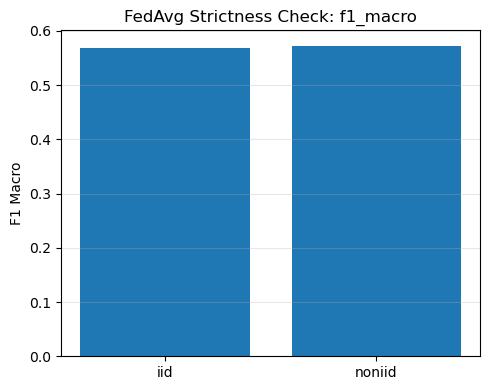

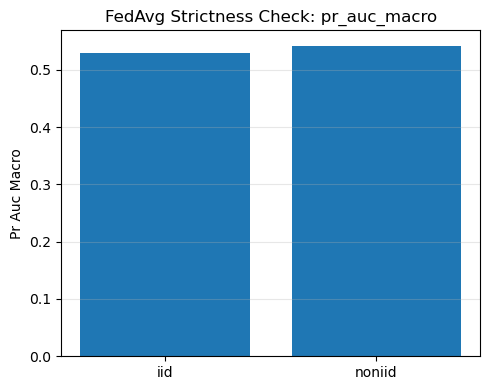

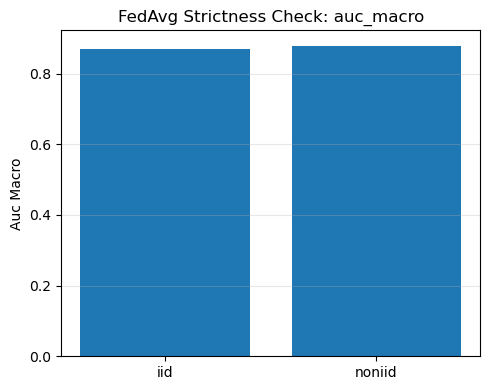

In [35]:
# Plot

strictness_df = pd.read_csv(STRICTNESS_CSV)

metrics_to_plot = ["f1_macro", "pr_auc_macro", "auc_macro"]

for metric in metrics_to_plot:
    plt.figure(figsize=(5, 4))
    ordered = strictness_df.set_index("split").loc[["iid", "noniid"]].reset_index()

    plt.bar(ordered["split"], ordered[metric])
    plt.title(f"FedAvg Strictness Check: {metric}")
    plt.ylabel(metric.replace("_", " ").title())
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
# Interpretation Hepler Cell

strictness_df = pd.read_csv(STRICTNESS_CSV)

if set(strictness_df["split"]) >= {"iid", "noniid"}:
    iid_row = strictness_df[strictness_df["split"] == "iid"].iloc[0]
    noniid_row = strictness_df[strictness_df["split"] == "noniid"].iloc[0]

    print("=== Strictness Check Summary ===")
    print(f"F1 Macro      : IID={iid_row['f1_macro']:.4f} | non-IID={noniid_row['f1_macro']:.4f} | delta={noniid_row['f1_macro'] - iid_row['f1_macro']:.4f}")
    print(f"PR-AUC Macro  : IID={iid_row['pr_auc_macro']:.4f} | non-IID={noniid_row['pr_auc_macro']:.4f} | delta={noniid_row['pr_auc_macro'] - iid_row['pr_auc_macro']:.4f}")
    print(f"AUC Macro     : IID={iid_row['auc_macro']:.4f} | non-IID={noniid_row['auc_macro']:.4f} | delta={noniid_row['auc_macro'] - iid_row['auc_macro']:.4f}")

=== Strictness Check Summary ===
F1 Macro      : IID=0.5680 | non-IID=0.5723 | delta=0.0044
PR-AUC Macro  : IID=0.5296 | non-IID=0.5419 | delta=0.0123
AUC Macro     : IID=0.8686 | non-IID=0.8784 | delta=0.0098


### Actual Sweep

In [ ]:
# =========================
# Baseline FL Sensitivity Sweep (FULL)
# =========================

client_counts = [2, 3, 5, 8, 10] #later 2,3,4,8,10,12,15,20

# keep fast first; later bump rounds / epochs to your real value
sweep_config = config.copy()
sweep_config["rounds"] = 10   # debug; set to 100 later if desired
sweep_config["epochs"] = 1

# choose non-IID severity (keep fixed across all methods)
noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

# best tuned method-specific hyperparameters from fixed baseline / attention setup
BEST_BASELINE_PARAMS = {
    "FedAvg": {
        "lr": 0.002,
        "mu": None,
        "momentum": None,
        "local_epochs": 1,   # use 3 later for final run
    },
    "FedProx": {
        "lr": 0.002,
        "mu": 0.001,
        "momentum": None,
        "local_epochs": 1,   # use 3 later for final run
    },
    "SCAFFOLD": {
        "lr": 1.25,
        "mu": None,
        "momentum": 0.0,
        "local_epochs": 1,   # use 3 later for final run
    },
}

# methods to compare
METHODS = [
    dict(method="FedAvg",   algo="FedAvg"),
    dict(method="FedProx",  algo="FedProx"),
    dict(method="SCAFFOLD", algo="SCAFFOLD"),
]

out_csv = BASELINE_SENS_CSV
out_json = BASELINE_SENS_JSON

# --- Resume / skip-completed support ---
if os.path.exists(out_csv):
    existing_df = pd.read_csv(out_csv)
    all_rows = existing_df.to_dict(orient="records")
    completed_keys = set(
        zip(
            existing_df["split"],
            existing_df["method"],
            existing_df["clients"]
        )
    )
    print(f"Found existing baseline sensitivity results at {out_csv}")
    print(f"Loaded {len(existing_df)} completed rows.")
else:
    all_rows = []
    completed_keys = set()
    print("No existing baseline sensitivity results found. Starting fresh.")

for split_mode in ["iid", "noniid"]:
    for m in METHODS:
        method_params = BEST_BASELINE_PARAMS[m["algo"]]

        for k in client_counts:
            run_key = (split_mode, m["method"], k)

            if run_key in completed_keys:
                print(f"Skipping completed run: {split_mode} | {m['method']} | K={k}")
                continue

            print(f"\n=== {split_mode.upper()} | {m['method']} | K={k} ===")

            trial_config = sweep_config.copy()
            trial_config["lr"] = method_params["lr"]

            try:
                metrics, elapsed = run_fl_sensitivity_once(
                    split_mode=split_mode,
                    num_clients=k,
                    local_epochs=method_params["local_epochs"],
                    config=trial_config,
                    train_dataset=train_dataset,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=device,
                    seed=42,
                    algo=m["algo"],
                    mu=(method_params["mu"] if method_params["mu"] is not None else 0.0),
                    momentum=(method_params["momentum"] if method_params["momentum"] is not None else 0.0),
                    **(noniid_params if split_mode == "noniid" else {})
                )

                row = {
                    "split": split_mode,
                    "method": m["method"],
                    "algo": m["algo"],
                    "lr": method_params["lr"],
                    "mu": method_params["mu"],
                    "momentum": method_params["momentum"],
                    "local_epochs": method_params["local_epochs"],
                    "rounds": trial_config["rounds"],
                    "clients": k,
                    "auc_macro": metrics.get("auc_macro"),
                    "auc_micro": metrics.get("auc_micro"),
                    "f1_macro": metrics.get("f1_macro"),
                    "f1_micro": metrics.get("f1_micro"),
                    "pr_auc_macro": metrics.get("pr_auc_macro"),
                    "pr_auc_micro": metrics.get("pr_auc_micro"),
                    "best_f1_micro": metrics.get("best_f1_micro"),
                    "best_thr": metrics.get("best_thr"),
                    "time_sec": elapsed,
                }

                if split_mode == "noniid":
                    row.update(noniid_params)

                all_rows.append(row)
                completed_keys.add(run_key)

                save_dict_rows_to_csv(all_rows, out_csv)
                save_json(
                    {"rows": [to_serializable_row(r) for r in all_rows]},
                    out_json
                )

                print(f"Saved result to {out_csv}")
                print(f"Saved result to {out_json}")

            except Exception as e:
                print(f"FAILED: {split_mode} | {m['method']} | K={k}")
                print(f"Reason: {e}")

print(f"\nBaseline sweep finished. Results saved to:")
print(f"  CSV : {out_csv}")
print(f"  JSON: {out_json}")

sens_all = pd.DataFrame(all_rows)
display(sens_all)

No existing baseline sensitivity results found. Starting fresh.

=== IID | FedAvg | K=2 ===


FedAvg iid | K=2 | E=1: 100%|██████████| 10/10 [01:00<00:00,  6.03s/it]


[Per-Label Thresholds] Macro F1=0.4789
[Eval] Avg loss=0.5026 | F1_micro=0.4742 | F1_macro=0.4978 | AUC_macro=0.8250 | AUC_micro=0.8487 | PR-AUC_macro=0.4434 | PR-AUC_micro=0.4989 | Best_F1=0.4742 @ thr=per-label | Avg labels/sample=10.95
Saved CSV: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.json

=== IID | FedAvg | K=3 ===


FedAvg iid | K=3 | E=1: 100%|██████████| 10/10 [00:43<00:00,  4.40s/it]


[Per-Label Thresholds] Macro F1=0.4469
[Eval] Avg loss=0.5333 | F1_micro=0.4470 | F1_macro=0.4709 | AUC_macro=0.8069 | AUC_micro=0.8320 | PR-AUC_macro=0.4067 | PR-AUC_micro=0.4687 | Best_F1=0.4470 @ thr=per-label | Avg labels/sample=11.78
Saved CSV: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.json

=== IID | FedAvg | K=5 ===


...

SCAFFOLD noniid | K=8 | E=1: 100%|██████████| 10/10 [00:57<00:00,  5.72s/it]


[Per-Label Thresholds] Macro F1=0.3416
[Eval] Avg loss=0.6304 | F1_micro=0.3417 | F1_macro=0.3466 | AUC_macro=0.7149 | AUC_micro=0.7275 | PR-AUC_macro=0.2814 | PR-AUC_micro=0.2748 | Best_F1=0.3417 @ thr=per-label | Avg labels/sample=17.60
Saved CSV: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.json

=== NONIID | SCAFFOLD | K=10 ===


SCAFFOLD noniid | K=10 | E=1: 100%|██████████| 10/10 [00:59<00:00,  5.95s/it]


[Per-Label Thresholds] Macro F1=0.3286
[Eval] Avg loss=0.6413 | F1_micro=0.3370 | F1_macro=0.3327 | AUC_macro=0.7103 | AUC_micro=0.7312 | PR-AUC_macro=0.2656 | PR-AUC_micro=0.2814 | Best_F1=0.3370 @ thr=per-label | Avg labels/sample=17.22
Saved CSV: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
Saved result to ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.json

Baseline sweep finished. Results saved to:
  CSV : ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv
  JSON: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.json


,split,method,algo,lr,mu,momentum,local_epochs,rounds,clients,auc_macro,...,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,FedAvg,FedAvg,0.002,NaN,NaN,1,10,2,0.824977,...,0.497800,0.474248,0.443387,0.498947,0.474248,per-label,62.363905,NaN,NaN,NaN
1,iid,FedAvg,FedAvg,0.002,NaN,NaN,1,10,3,0.806900,...,0.470852,0.447009,0.406654,0.468744,0.447009,per-label,45.749619,NaN,NaN,NaN
2,iid,FedAvg,FedAvg,0.002,NaN,NaN,1,10,5,0.762623,...,0.408018,0.389672,0.343486,0.373761,0.389672,per-label,46.771039,NaN,NaN,NaN
3,iid,FedAvg,FedAvg,0.002,NaN,NaN,1,10,8,0.732168,...,0.365456,0.354736,0.298323,0.318307,0.354736,per-label,49.148393,NaN,NaN,NaN
4,iid,FedAvg,FedAvg,0.002,NaN,NaN,1,10,10,0.729091,...,0.366013,0.351960,0.294871,0.324890,0.351960,per-label,49.680054,NaN,NaN,NaN
5,iid,FedProx,FedProx,0.002,0.001,NaN,1,10,2,0.819558,...,0.491621,0.465071,0.433038,0.492858,0.465071,per-label,49.153963,NaN,NaN,NaN
6,iid,FedProx,FedProx,0.002,0.001,NaN,1,10,3,0.795126,...,0.453886,0.427830,0.392245,0.444230,0.427830,per-label,49.519946,NaN,NaN,NaN
7,iid,FedProx,FedProx,0.002,0.001,NaN,1,10,5,0.767085,...,0.410025,0.398101,0.343983,0.368834,0.398101,per-label,50.294950,NaN,NaN,NaN
8,iid,FedProx,FedProx,0.002,0.001,NaN,1,10,8,0.730542,...,0.365981,0.362078,0.300023,0.326371,0.362078,per-label,52.147972,NaN,NaN,NaN
9,iid,FedProx,FedProx,0.002,0.001,NaN,1,10,10,0.749024,...,0.384294,0.369735,0.322358,0.343293,0.369735,per-label,53.059385,NaN,NaN,NaN


In [ ]:
# Load + table (primary metrics)

out_csv = BASELINE_SENS_CSV
sens_all = pd.read_csv(out_csv)
print("Loaded:", out_csv, "rows=", len(sens_all))

# Comparison table: primary metrics + method-specific hyperparameters
table = sens_all[[
    "split",
    "method",
    "clients",
    "lr",
    "mu",
    "momentum",
    "local_epochs",
    "rounds",
    "f1_macro",
    "pr_auc_macro",
    "auc_macro",
    "time_sec"
]].copy()

display(table)

Loaded: ..\History\KD\baseline_fl_sensitivity\baseline_sensitivity_results.csv rows= 30


,split,method,clients,lr,mu,momentum,local_epochs,rounds,f1_macro,pr_auc_macro,auc_macro,time_sec
0,iid,FedAvg,2,0.002,NaN,NaN,1,10,0.497800,0.443387,0.824977,62.363905
1,iid,FedAvg,3,0.002,NaN,NaN,1,10,0.470852,0.406654,0.806900,45.749619
2,iid,FedAvg,5,0.002,NaN,NaN,1,10,0.408018,0.343486,0.762623,46.771039
3,iid,FedAvg,8,0.002,NaN,NaN,1,10,0.365456,0.298323,0.732168,49.148393
4,iid,FedAvg,10,0.002,NaN,NaN,1,10,0.366013,0.294871,0.729091,49.680054
5,iid,FedProx,2,0.002,0.001,NaN,1,10,0.491621,0.433038,0.819558,49.153963
6,iid,FedProx,3,0.002,0.001,NaN,1,10,0.453886,0.392245,0.795126,49.519946
7,iid,FedProx,5,0.002,0.001,NaN,1,10,0.410025,0.343983,0.767085,50.294950
8,iid,FedProx,8,0.002,0.001,NaN,1,10,0.365981,0.300023,0.730542,52.147972
9,iid,FedProx,10,0.002,0.001,NaN,1,10,0.384294,0.322358,0.749024,53.059385


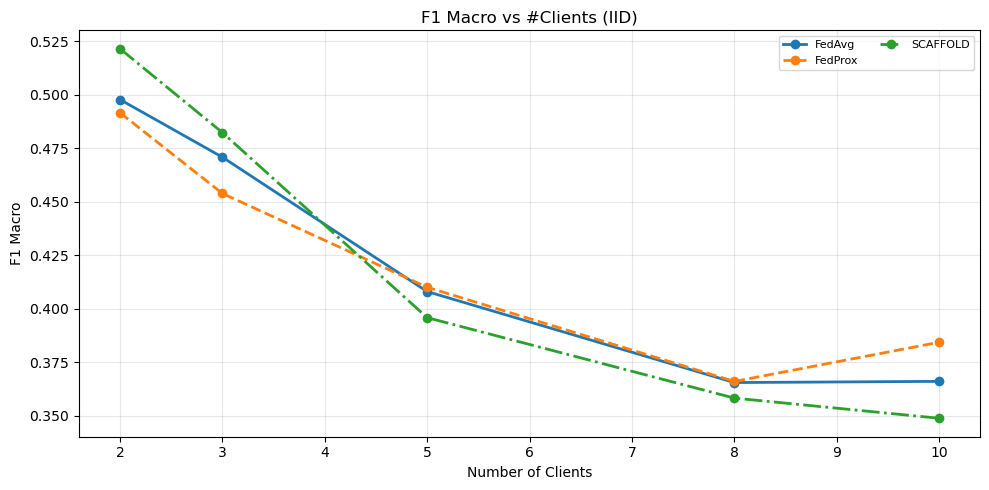

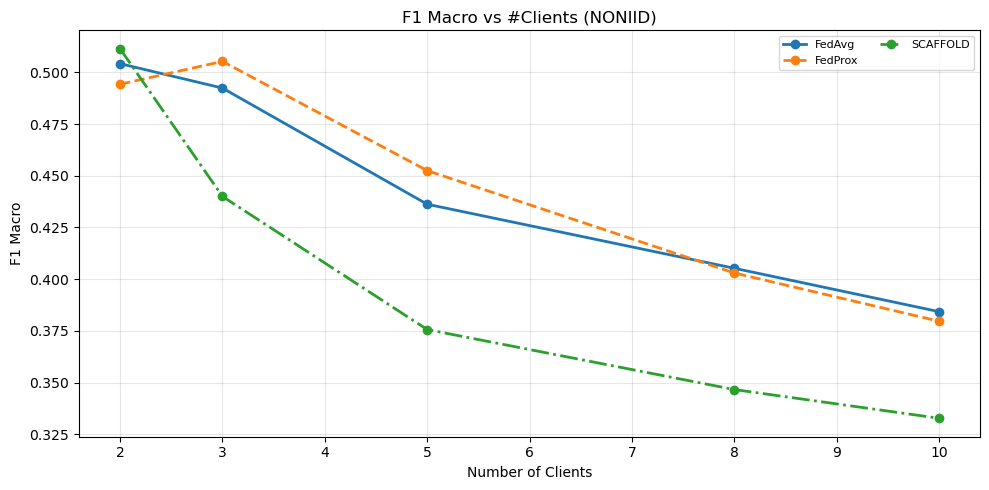

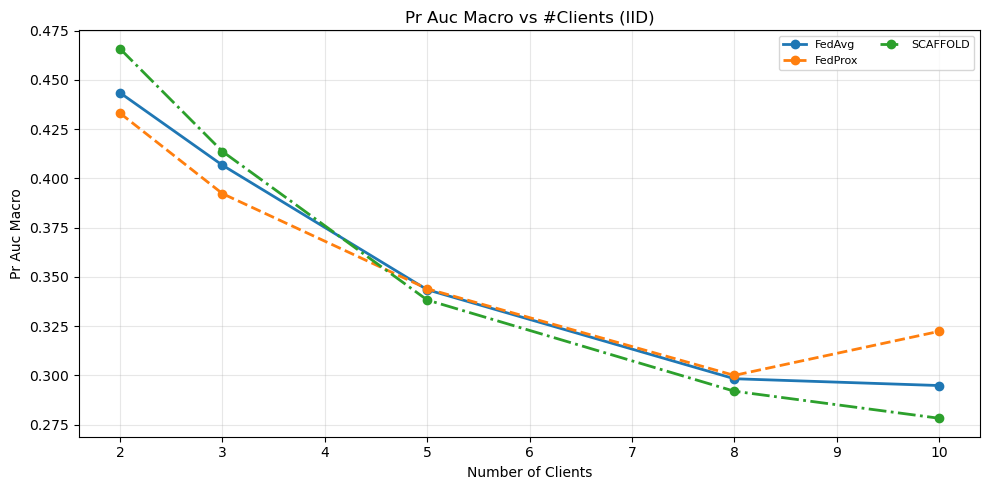

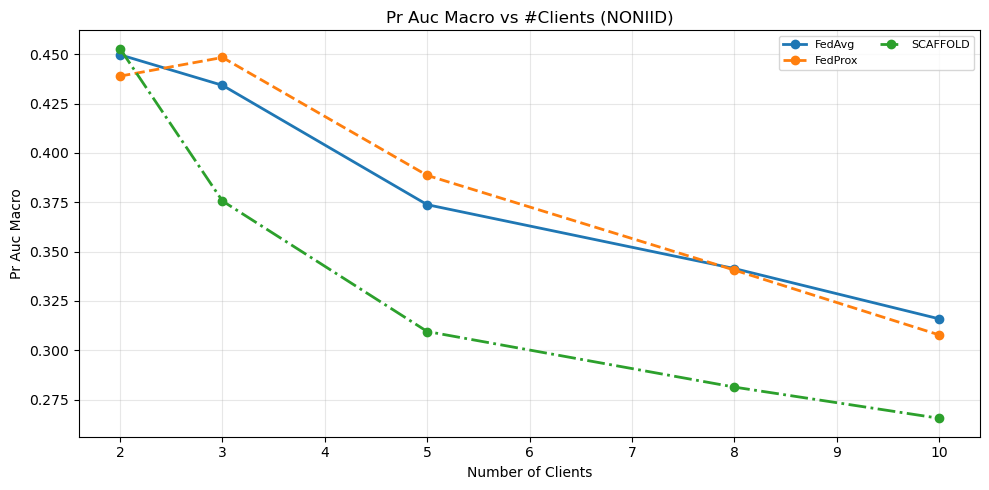

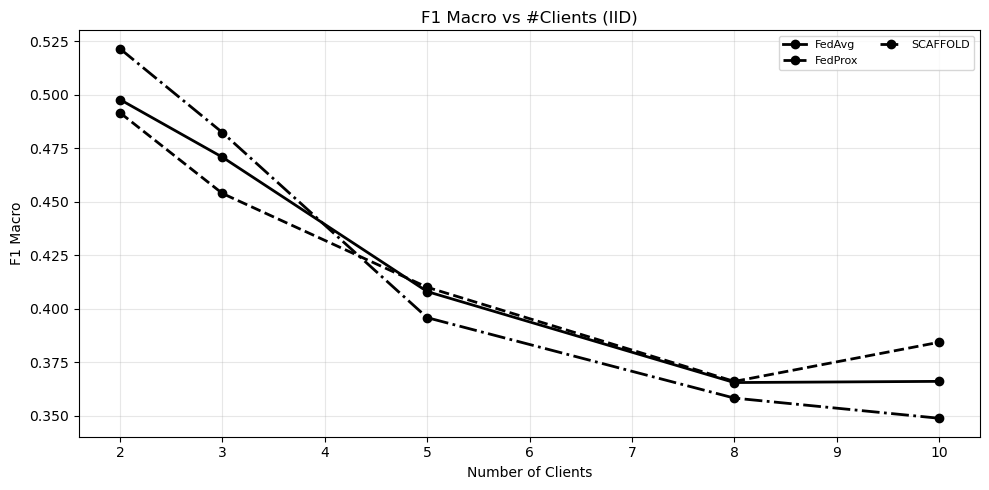

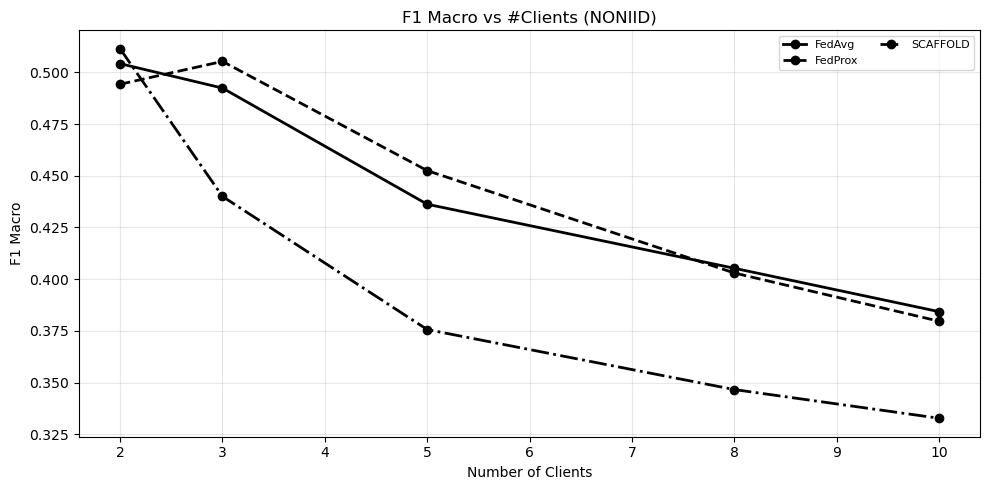

In [ ]:
# Plotting

# Pre-define visually distinct markers/linestyles (works for both color and B/W)
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5)), (0, (1, 1))]

def plot_metric_all_methods(df, split_mode: str, metric: str = "f1_macro", bw: bool = False):
    d = df[df["split"] == split_mode].copy()

    # consistent order in legend
    methods = sorted(d["method"].unique())

    plt.figure(figsize=(10, 5))

    style_cycle = itertools.cycle([
        (m, ls) for m in MARKERS for ls in LINESTYLES
    ])

    for method in methods:
        g = d[d["method"] == method].sort_values("clients")
        marker, ls = next(style_cycle)

        if bw:
            plt.plot(
                g["clients"], g[metric],
                color="black",
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g[metric],
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs #Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncols=2, frameon=True)
    plt.tight_layout()
    plt.show()

# Color
plot_metric_all_methods(sens_all, "iid", metric="f1_macro", bw=False)
plot_metric_all_methods(sens_all, "noniid", metric="f1_macro", bw=False)

plot_metric_all_methods(sens_all, "iid", metric="pr_auc_macro", bw=False)
plot_metric_all_methods(sens_all, "noniid", metric="pr_auc_macro", bw=False)

# Black & White
plot_metric_all_methods(sens_all, "iid", metric="f1_macro", bw=True)
plot_metric_all_methods(sens_all, "noniid", metric="f1_macro", bw=True)

## Knowledge Distillation Extensions (Option 1 and Option 3)

This section adds two KD-based federated training variants for the multi-label ICD task:

**Option 1 — Local KD / Drift Control**
- Each client receives the current global model.
- A frozen copy acts as the **teacher**.
- A trainable copy acts as the **student**.
- The student is trained on:
  - supervised BCE loss on ground-truth labels
  - KD loss against the frozen global teacher

**Option 3 — Local Heterogeneous Teacher → Global Student**
- The server maintains a shared global **student** model.
- Each client maintains its own persistent local **teacher**.
- The teacher is trained locally on hard labels.
- The student is trained on:
  - supervised BCE loss
  - KD loss against the local teacher

Notes:
- These implementations are designed for **multi-label** prediction.
- Server-side distillation is supported as an optional post-aggregation refinement step.
- FedProx compatibility is included by applying the proximal penalty to the uploaded student model.
- In this notebook, server distillation follows the toy reference and uses client mini-batches
  as the distillation input source. For a stricter privacy setup, this can later be replaced
  with a proxy/public dataset without changing the client-side KD code.

In [ ]:
# Suggested teacher pool:
# - "medium" teacher: modest capacity increase over student
# - "mullenbach" teacher: closer to stronger CAML-style settings
# - "wide" teacher: even larger local teacher
#
# You can adjust these later, but this is a good first pool.
# We may have to track things like overfitting for the larger mdoels later

option3_teacher_pool = [
    {"name": "t1_light",     "num_of_filters": 28, "kernel_size": 4,  "drop_out": 0.2},
    {"name": "t2_medium",    "num_of_filters": 36, "kernel_size": 6,  "drop_out": 0.2},
    {"name": "t3_caml_ref",  "num_of_filters": 50, "kernel_size": 10, "drop_out": 0.2},  # Mullenbach
    {"name": "t4_large",     "num_of_filters": 64, "kernel_size": 10, "drop_out": 0.2},
    {"name": "t5_xlarge",    "num_of_filters": 80, "kernel_size": 12, "drop_out": 0.2},
]

# KD configuration defaults (can be adjusted later)

kd_config = {
    "kd_alpha": 0.5,             # weight on supervised loss
    "kd_temperature": 2.0,       # temperature for KD

    # Option 3 teacher-pool config
    "teacher_pool": option3_teacher_pool,
    "teacher_assignment": "round_robin",
    "teacher_steps_per_batch": 1,

    # Server distillation config
    "server_distill_steps": 10,   # number of server KD refinement steps after aggregation
    "server_distill_lr": 0.002,   # optimizer LR for server KD phase
}

### KD Loss Utilities

For this ICD setting, the task is **multi-label**, so we do not use softmax distillation.
Instead, we match temperature-scaled sigmoid outputs label-wise.

In [ ]:
def build_supervised_loss(
    train_loader,
    n_labels,
    use_focal: bool = False,
    gamma: float = 2.5,
    device: str = "cpu"
):
    """
    Build the supervised loss used for a client's local dataset.
    """
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        return FocalLoss(alpha=alpha, gamma=gamma)
    else:
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def multilabel_kd_loss(student_logits, teacher_logits, temperature: float = 2.0):
    """
    Multi-label KD loss using temperature-scaled sigmoid probabilities.

    This behaves like a binary KL-style matching loss across labels.
    """
    T = temperature

    teacher_probs = torch.sigmoid(teacher_logits / T)
    student_probs = torch.sigmoid(student_logits / T)

    kd = F.binary_cross_entropy(
        student_probs,
        teacher_probs,
        reduction="mean"
    )

    return kd * (T * T)

In [ ]:
# Helpers for FedDKD

# Helper to rebuild client models from uploaded state dicts
def build_student_model_from_state(
    state_dict: dict,
    table_path: str,
    config: dict,
    device: str = "cpu"
):
    """
    Rebuild a student/global-compatible model from a state_dict.
    Used so the server can treat returned client students/models as teachers
    during the server distillation phase.
    """
    model = GenerateModel(
        table_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model

# Multi-label server distillation engine
def execute_server_distillation(
    global_model: nn.Module,
    client_teacher_models: list[nn.Module],
    client_loaders: list[DataLoader],
    client_sizes: list[int],
    kd_temperature: float = 2.0,
    distill_steps: int = 10,
    distill_lr: float = 0.002,
    device: str = "cpu"
):
    """
    Post-aggregation server distillation phase.

    Procedure:
    1. Global model is already initialized from weighted FedAvg.
    2. Each returned client model/student acts as a teacher.
    3. For each server KD step, the server pulls one batch from each client's loader.
    4. The global model is optimized to match each teacher on that client's batch.

    Important:
    - This mirrors the toy notebook's pattern and is NOT privacy-clean for deployment.
    - For stricter settings, replace client_loaders with a proxy/public distillation loader.
    """
    global_model.train()
    optimizer = torch.optim.Adam(global_model.parameters(), lr=distill_lr, betas=(0.9, 0.99))

    total_size = float(sum(client_sizes))
    client_weights = [sz / total_size for sz in client_sizes]

    client_iters = [iter(loader) for loader in client_loaders]

    for teacher in client_teacher_models:
        teacher.eval()

    for _ in range(distill_steps):
        optimizer.zero_grad()
        total_loss = 0.0

        for cid, teacher in enumerate(client_teacher_models):
            try:
                X_batch, _ = next(client_iters[cid])
            except StopIteration:
                client_iters[cid] = iter(client_loaders[cid])
                X_batch, _ = next(client_iters[cid])

            X_batch = X_batch.to(device)

            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            student_logits, _ = global_model(X_batch)

            kd_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            weighted_loss = client_weights[cid] * kd_loss
            weighted_loss.backward()
            total_loss += weighted_loss.item()

        optimizer.step()

    return global_model

### Proximal Regularization Helper

Used when combining Option 1 or Option 3 with FedProx.
The proximal penalty is applied only to the uploaded student model.

In [ ]:
def proximal_term(model: nn.Module, global_params: dict, device: str = "cpu"):
    """
    Compute FedProx proximal penalty relative to the received global model.
    """
    prox = 0.0
    for name, param in model.named_parameters():
        prox += torch.norm(param - global_params[name].to(device), p=2) ** 2
    return prox

### Option 1 — Local KD / Drift Control

Teacher: frozen copy of the global model  
Student: trainable local copy initialized from the same global model

In [ ]:
def client_update_option1(
    global_model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01
):
    """
    Option 1:
    - teacher = frozen global model
    - student = local trainable model
    - local loss = supervised + KD (+ optional FedProx penalty)
    """
    teacher = copy.deepcopy(global_model).to(device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    student = copy.deepcopy(global_model).to(device)
    student.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_model.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    optimizer = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            student_logits, _ = student(X_batch)
            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            optimizer.step()

            last_loss = loss.item()

    return last_loss, student.state_dict()

### Option 3 — Local Heterogeneous Teacher Pool -> Global Student

Teacher: persistent local client model drawn from a heterogeneous CAML-style teacher pool  
Student: shared global model copied locally each round

Instead of assigning every client the same larger teacher, we assign each client
a persistent teacher profile from a pool of five ConvAttnPool variants. The pool
is centered around a CAML reference configuration inspired by Mullenbach et al.,
with both smaller and larger capacity variants included.

This keeps the student architecture homogeneous for aggregation while making the
local teachers more meaningfully heterogeneous in capacity and receptive field.

In [ ]:
def build_teacher_from_profile(table_path: str, profile: dict) -> ConvAttnPool:
    """
    Build a local Option 3 teacher from a teacher profile dictionary.
    """
    return ConvAttnPool(
        table_path=table_path,
        label_space=50,
        num_of_filters=profile["num_of_filters"],
        kernel_size=profile["kernel_size"],
        drop_out=profile.get("drop_out", 0.2)
    )

def initialize_option3_teachers(
    num_clients: int,
    table_path: str,
    teacher_pool: list[dict],
    assignment: str = "round_robin",
    seed: int = 42,
    device: str = "cpu"
):
    """
    Create one persistent local teacher per client from a heterogeneous teacher pool.

    Returns:
        teachers: list of nn.Module
        teacher_profiles: list of dicts describing the assigned profile for each client
    """
    if len(teacher_pool) == 0:
        raise ValueError("teacher_pool must contain at least one teacher profile")

    rng = np.random.default_rng(seed)

    if assignment == "round_robin":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[i % len(teacher_pool)])
            for i in range(num_clients)
        ]
    elif assignment == "random":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[rng.integers(0, len(teacher_pool))])
            for _ in range(num_clients)
        ]
    else:
        raise ValueError("assignment must be 'round_robin' or 'random'")

    teachers = []
    for profile in teacher_profiles:
        teacher = build_teacher_from_profile(table_path, profile).to(device)
        teachers.append(teacher)

    return teachers, teacher_profiles

In [ ]:
def client_update_option3(
    global_student: nn.Module,
    local_teacher: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01,
    teacher_steps_per_batch: int = 1
):
    """
    Option 3:
    - local teacher persists on client
    - teacher trains on hard labels
    - student trains on supervised + KD from teacher
    - only student weights are uploaded
    - optional FedProx penalty is applied to the student only

    teacher_steps_per_batch:
        number of teacher optimization steps before one student update.
        keep at 1 initially.
    """
    student = copy.deepcopy(global_student).to(device)
    teacher = local_teacher.to(device)

    student.train()
    teacher.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_student.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    student_opt = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))
    teacher_opt = torch.optim.Adam(teacher.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # ---- Teacher update on hard labels ----
            for _ts in range(teacher_steps_per_batch):
                teacher_opt.zero_grad()
                teacher_logits, _ = teacher(X_batch)
                teacher_loss = sup_loss_fn(teacher_logits, y_batch)
                teacher_loss.backward()
                teacher_opt.step()

            # ---- Student update on hard labels + teacher KD ----
            student_opt.zero_grad()
            student_logits, _ = student(X_batch)

            with torch.no_grad():
                teacher_logits_detached, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits_detached,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            student_opt.step()

            last_loss = loss.item()

    return last_loss, student.state_dict(), teacher

### KD-Capable Federated Runner

This runner supports:
- baseline FedAvg / FedProx
- Option 1
- Option 3

Server distillation is not included yet.

In [ ]:
def run_fl_kd_once(
    split_mode: str,             # "iid" or "noniid"
    num_clients: int,
    local_epochs: int,
    config: dict,
    kd_config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    method: str = "baseline",    # "baseline", "option1", "option3"
    base_algo: str = "FedAvg",   # "FedAvg" or "FedProx"
    mu: float = 0.01,
    server_distill: bool = False,
    # non-IID params
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85
):
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(train_dataset, num_clients=num_clients, seed=seed)
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- global shared model / student ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    # --- persistent teachers for Option 3 ---
    local_teachers = None
    teacher_profiles = None
    if method == "option3":
        local_teachers, teacher_profiles = initialize_option3_teachers(
            num_clients=num_clients,
            table_path=model_param_path,
            teacher_pool=kd_config["teacher_pool"],
            assignment=kd_config.get("teacher_assignment", "round_robin"),
            seed=seed,
            device=device
        )

    # --- rounds ---
    for rnd in tqdm(
        range(config["rounds"]),
        colour="blue",
        desc=(
            f"{method} | {base_algo}"
            f"{' + SD' if server_distill else ''} | {split_mode} | K={num_clients} | E={local_epochs}"
        )
    ):
        client_params = []
        client_teacher_models = []

        for cid, loader in enumerate(client_loaders):
            if method == "baseline":
                client_model = copy.deepcopy(global_model)

                _, client_state, _ = client_update(
                    model=client_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    mu=mu,
                    global_params=(global_model.state_dict() if base_algo == "FedProx" else None),
                    c_global=None,
                    c_local=None,
                    algorithm=base_algo
                )
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option1":
                _, client_state = client_update_option1(
                    global_model=global_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu
                )
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option3":
                _, client_state, updated_teacher = client_update_option3(
                    global_student=global_model,
                    local_teacher=local_teachers[cid],
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu,
                    teacher_steps_per_batch=kd_config.get("teacher_steps_per_batch", 1)
                )
                local_teachers[cid] = updated_teacher
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            else:
                raise ValueError("method must be one of: baseline, option1, option3")

        # --- first do standard weighted aggregation ---
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

        # --- optional server distillation refinement ---
        if server_distill:
            global_model = execute_server_distillation(
                global_model=global_model,
                client_teacher_models=client_teacher_models,
                client_loaders=client_loaders,
                client_sizes=client_sizes,
                kd_temperature=kd_config["kd_temperature"],
                distill_steps=kd_config.get("server_distill_steps", 10),
                distill_lr=kd_config.get("server_distill_lr", config["lr"]),
                device=device
            )

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time

    # optional logging fields for bookkeeping
    metrics["server_distill"] = bool(server_distill)
    metrics["method"] = method
    metrics["base_algo"] = base_algo
    if method == "option3" and teacher_profiles is not None:
        metrics["teacher_profiles"] = [tp["name"] for tp in teacher_profiles]

    return metrics, elapsed

### Quick KD + FedProx Smoke Tests

Run a small sanity check on the current method set before launching the full sweep.

Current methods:
- Baseline FedAvg
- Baseline FedProx (mu = 0.01)
- Option 1 + FedAvg
- Option 1 + FedAvg + Server Distillation
- Option 1 + FedProx (mu = 0.01)
- Option 1 + FedProx + Server Distillation
- Option 3 + FedAvg
- Option 3 + FedAvg + Server Distillation
- Option 3 + FedProx (mu = 0.01)
- Option 3 + FedProx + Server Distillation

Setup:
- non-IID split
- 2 clients
- 1 local epoch
- fixed non-IID severity

In [ ]:
# %%
def clean_metrics(metrics: dict):
    out = {}
    for k, v in metrics.items():
        if isinstance(v, (np.floating, float)):
            out[k] = float(v)
        else:
            out[k] = v
    return out


def print_metrics(title: str, metrics: dict, time_sec: float):
    m = clean_metrics(metrics)

    print(f"\n=== {title} ===")
    print(f"Time          : {time_sec:.2f}s")
    print(f"F1 Macro      : {m.get('f1_macro', float('nan')):.4f}")
    print(f"F1 Micro      : {m.get('f1_micro', float('nan')):.4f}")
    print(f"AUC Macro     : {m.get('auc_macro', float('nan')):.4f}")
    print(f"AUC Micro     : {m.get('auc_micro', float('nan')):.4f}")
    print(f"PR-AUC Macro  : {m.get('pr_auc_macro', float('nan')):.4f}")
    print(f"PR-AUC Micro  : {m.get('pr_auc_micro', float('nan')):.4f}")


def compare_methods(results: dict):
    rows = []
    for name, (metrics, time_sec) in results.items():
        m = clean_metrics(metrics)
        rows.append({
            "method": name,
            "f1_macro": m.get("f1_macro"),
            "f1_micro": m.get("f1_micro"),
            "pr_auc_macro": m.get("pr_auc_macro"),
            "pr_auc_micro": m.get("pr_auc_micro"),
            "auc_macro": m.get("auc_macro"),
            "auc_micro": m.get("auc_micro"),
            "time_sec": round(time_sec, 2)
        })

    df = pd.DataFrame(rows).sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    ).reset_index(drop=True)

    display(df)
    return df

In [ ]:
# Shared smoke-test settings

smoke_kwargs = dict(
    split_mode="noniid",
    num_clients=2,
    local_epochs=1,
    config=config,
    kd_config=kd_config,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    seed=42,
    mu=0.01,
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

In [ ]:
# # 1) Baseline FedAvg

# smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg = run_fl_kd_once(
#     method="baseline",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Baseline FedAvg", smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg)

In [ ]:
# # 2) Baseline FedProx

# smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox = run_fl_kd_once(
#     method="baseline",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Baseline FedProx (mu=0.01)", smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox)

In [ ]:
# # 3) Option 1 + FedAvg

# smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg = run_fl_kd_once(
#     method="option1",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedAvg", smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg)

In [ ]:
# # 4) Option 1 + FedAvg + FedDKD

# smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd = run_fl_kd_once(
#     method="option1",
#     base_algo="FedAvg",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedAvg + Server Distill", smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd)

In [ ]:
# # 5) Option 1 + FedProx

# smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox = run_fl_kd_once(
#     method="option1",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedProx (mu=0.01)", smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox)

In [ ]:
# # 6) Option 1 + FedProx + FedDKD

# smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd = run_fl_kd_once(
#     method="option1",
#     base_algo="FedProx",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedProx + Server Distill (mu=0.01)", smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd)

In [ ]:
# # 7) Option 3 + FedAvg

# smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedAvg", smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg)

In [ ]:
# # 8) Option 3 + FedAvg + FedDKD

# smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedAvg + Server Distill", smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd)

In [ ]:
# # 9) Option 3 + FedProx

# smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox = run_fl_kd_once(
#     method="option3",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedProx (mu=0.01)", smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox)

In [ ]:
# # 10) Option 3 + FedProx + FedDKD

# smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd = run_fl_kd_once(
#     method="option3",
#     base_algo="FedProx",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedProx + Server Distill (mu=0.01)", smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd)

In [ ]:
# # Combined comparison table

# smoke_df = compare_methods({
#     "Baseline_FedAvg": (smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg),
#     "Baseline_FedProx_mu0.01": (smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox),

#     "Opt1_FedAvg": (smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg),
#     "Opt1_FedAvg_SD": (smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd),
#     "Opt1_FedProx_mu0.01": (smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox),
#     "Opt1_FedProx_mu0.01_SD": (smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd),

#     "Opt3_FedAvg": (smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg),
#     "Opt3_FedAvg_SD": (smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd),
#     "Opt3_FedProx_mu0.01": (smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox),
#     "Opt3_FedProx_mu0.01_SD": (smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd),
# })

## Actual Client Sweep for KD

In [ ]:
# This section runs the full experiment matrix across client counts and split types.
# Results are saved incrementally to CSV and can be plotted afterward.

client_counts = [2, 3, 5, 8, 10]

sweep_config = config.copy()
sweep_config["rounds"] = 10   # keep or change as needed

noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

KD_METHODS = [
    dict(method_name="Baseline_FedAvg",            method="baseline", base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Baseline_FedProx_mu0.01",    method="baseline", base_algo="FedProx", mu=0.01, server_distill=False),

    dict(method_name="Opt1_FedAvg",                method="option1",  base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Opt1_FedAvg_SD",             method="option1",  base_algo="FedAvg",  mu=0.0,  server_distill=True),
    dict(method_name="Opt1_FedProx_mu0.01",        method="option1",  base_algo="FedProx", mu=0.01, server_distill=False),
    dict(method_name="Opt1_FedProx_mu0.01_SD",     method="option1",  base_algo="FedProx", mu=0.01, server_distill=True),

    dict(method_name="Opt3_FedAvg",                method="option3",  base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Opt3_FedAvg_SD",             method="option3",  base_algo="FedAvg",  mu=0.0,  server_distill=True),
    dict(method_name="Opt3_FedProx_mu0.01",        method="option3",  base_algo="FedProx", mu=0.01, server_distill=False),
    dict(method_name="Opt3_FedProx_mu0.01_SD",     method="option3",  base_algo="FedProx", mu=0.01, server_distill=True),
]

# out_path = "../History/kd_client_sweep_results_r10_e1.csv"
out_path = os.path.join(KD_HISTORY_DIR, "kd_client_sweep_results_r10_e1.csv")

In [ ]:
# # Sweep runner with resume / skip-completed support

# if os.path.exists(out_path):
#     kd_sweep_df_existing = pd.read_csv(out_path)
#     all_rows = kd_sweep_df_existing.to_dict(orient="records")
#     completed_keys = set(
#         zip(
#             kd_sweep_df_existing["split"],
#             kd_sweep_df_existing["method_name"],
#             kd_sweep_df_existing["clients"]
#         )
#     )
#     print(f"Found existing results at {out_path}")
#     print(f"Loaded {len(kd_sweep_df_existing)} completed rows.")
# else:
#     all_rows = []
#     completed_keys = set()
#     print("No existing results found. Starting fresh.")

# for split_mode in ["iid", "noniid"]:
#     for m in KD_METHODS:
#         for k in client_counts:
#             run_key = (split_mode, m["method_name"], k)

#             if run_key in completed_keys:
#                 print(f"Skipping completed run: {split_mode} | {m['method_name']} | K={k}")
#                 continue

#             print(f"\n=== {split_mode.upper()} | {m['method_name']} | K={k} ===")

#             try:
#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode=split_mode,
#                     num_clients=k,
#                     local_epochs=1,   # or 3 if you want the heavier final setting
#                     config=sweep_config,
#                     kd_config=kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method=m["method"],
#                     base_algo=m["base_algo"],
#                     mu=m["mu"],
#                     server_distill=m["server_distill"],
#                     **(noniid_params if split_mode == "noniid" else {})
#                 )

#                 row = {
#                     "split": split_mode,
#                     "clients": k,

#                     "method_name": m["method_name"],
#                     "method": m["method"],
#                     "base_algo": m["base_algo"],
#                     "mu": m["mu"],
#                     "server_distill": m["server_distill"],

#                     "local_epochs": 1,
#                     "rounds": sweep_config["rounds"],

#                     "kd_alpha": kd_config["kd_alpha"],
#                     "kd_temperature": kd_config["kd_temperature"],
#                     "server_distill_steps": kd_config.get("server_distill_steps", None),
#                     "server_distill_lr": kd_config.get("server_distill_lr", None),

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),

#                     "time_sec": elapsed,
#                 }

#                 if split_mode == "noniid":
#                     row.update(noniid_params)

#                 all_rows.append(row)
#                 completed_keys.add(run_key)

#                 pd.DataFrame(all_rows).to_csv(out_path, index=False)
#                 print(f"Saved result to {out_path}")

#             except Exception as e:
#                 print(f"FAILED: {split_mode} | {m['method_name']} | K={k}")
#                 print(f"Reason: {e}")

# print(f"\nSweep finished. Results saved to: {out_path}")

# kd_sweep_df = pd.DataFrame(all_rows)
# display(kd_sweep_df.head())

In [ ]:
# Reload saved CSV later if needed

kd_sweep_df = pd.read_csv(out_path)
print("Loaded:", out_path, "rows=", len(kd_sweep_df))
display(kd_sweep_df.head())

Loaded: ../History/KD/kd_client_sweep_results_r10_e1.csv rows= 100


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.443387,0.498947,0.824977,0.848693,0.474248,per-label,40.960412,NaN,NaN,NaN
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.406654,0.468744,0.806900,0.832006,0.447009,per-label,35.902688,NaN,NaN,NaN
2,iid,5,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.343486,0.373761,0.762623,0.784956,0.389672,per-label,36.214020,NaN,NaN,NaN
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.298323,0.318307,0.732168,0.748686,0.354736,per-label,37.139290,NaN,NaN,NaN
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.294871,0.324890,0.729091,0.748564,0.351960,per-label,37.537419,NaN,NaN,NaN


In [ ]:
# Best-performing rows by split (summary table)
summary_cols = [
    "split", "clients", "method_name",
    "f1_macro", "f1_micro",
    "pr_auc_macro", "pr_auc_micro",
    "auc_macro", "auc_micro",
    "time_sec"
]

summary_table = kd_sweep_df[summary_cols].copy()
display(summary_table)

,split,clients,method_name,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,time_sec
0,iid,2,Baseline_FedAvg,0.497800,0.474248,0.443387,0.498947,0.824977,0.848693,40.960412
1,iid,3,Baseline_FedAvg,0.470852,0.447009,0.406654,0.468744,0.806900,0.832006,35.902688
2,iid,5,Baseline_FedAvg,0.408018,0.389672,0.343486,0.373761,0.762623,0.784956,36.214020
3,iid,8,Baseline_FedAvg,0.365456,0.354736,0.298323,0.318307,0.732168,0.748686,37.139290
4,iid,10,Baseline_FedAvg,0.366013,0.351960,0.294871,0.324890,0.729091,0.748564,37.537419
...,...,...,...,...,...,...,...,...,...,...
95,noniid,2,Opt3_FedProx_mu0.01_SD,0.429274,0.414305,0.365910,0.397774,0.774296,0.804267,97.892004
96,noniid,3,Opt3_FedProx_mu0.01_SD,0.438682,0.391019,0.366164,0.436070,0.771906,0.806058,111.300764
97,noniid,5,Opt3_FedProx_mu0.01_SD,0.405536,0.389947,0.335138,0.376868,0.757646,0.784299,136.016194
98,noniid,8,Opt3_FedProx_mu0.01_SD,0.367000,0.351503,0.292969,0.311675,0.729705,0.750646,173.249655


In [ ]:
# Pivot table for Macro F1

pivot_f1 = kd_sweep_df.pivot_table(
    index=["split", "clients"],
    columns="method_name",
    values="f1_macro"
)

display(pivot_f1)

method_name     Baseline_FedAvg  Baseline_FedProx_mu0.01  Opt1_FedAvg  \
split  clients                                                          
iid    2               0.497800                 0.456414     0.495233   
       3               0.470852                 0.413290     0.462789   
       5               0.408018                 0.391733     0.397906   
       8               0.365456                 0.359903     0.377801   
       10              0.366013                 0.371659     0.370527   
noniid 2               0.490498                 0.461837     0.492520   
       3               0.489066                 0.453947     0.498715   
       5               0.448327                 0.418679     0.459545   
       8               0.430108                 0.388796     0.413070   
       10              0.373330                 0.362807     0.383096   

method_name     Opt1_FedAvg_SD  Opt1_FedProx_mu0.01  Opt1_FedProx_mu0.01_SD  \
split  clients                                                                
iid    2              0.491546             0.393192                0.378978   
       3              0.451041             0.386103                0.375408   
       5              0.409090             0.370528                0.364026   
       8              0.364004             0.350768                0.368619   
       10             0.363424             0.344766                0.352808   
noniid 2              0.482147             0.382895                0.384783   
       3              0.482311             0.406594                0.390929   
       5              0.451185             0.375075                0.388597   
       8              0.403927             0.345698                0.351533   
       10             0.405551             0.355472                0.361634   

method_name     Opt3_FedAvg  Opt3_FedAvg_SD  Opt3_FedProx_mu0.01  \
split  clients                                                     
iid    2           0.499363        0.496921             0.429485   
       3           0.462638        0.459803             0.400138   
       5           0.395589        0.401832             0.375128   
       8           0.371401        0.373030             0.362886   
       10          0.360442        0.358899             0.344652   
noniid 2           0.501441        0.496286             0.422238   
       3           0.506945        0.497678             0.438694   
       5           0.449288        0.448400             0.402613   
       8           0.398795        0.422080             0.377005   
       10          0.380120        0.393621             0.365139   

method_name     Opt3_FedProx_mu0.01_SD  
split  clients                          
iid    2                      0.435784  
       3                      0.408136  
       5                      0.362662  
       8                      0.354452  
       10                     0.346373  
noniid 2                      0.429274  
       3                      0.438682  
       5                      0.405536  
       8                      0.367000  
       10                     0.357302

In [ ]:
# General plotting helper

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5)), (0, (1, 1))]

def plot_metric_all_methods(df, split_mode: str, metric: str = "f1_macro", bw: bool = False):
    d = df[df["split"] == split_mode].copy()
    methods = sorted(d["method_name"].unique())

    plt.figure(figsize=(11, 5))
    style_pairs = list(itertools.product(MARKERS, LINESTYLES))

    for i, method in enumerate(methods):
        g = d[d["method_name"] == method].sort_values("clients")
        marker, ls = style_pairs[i % len(style_pairs)]

        if bw:
            plt.plot(
                g["clients"], g[metric],
                color="black",
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g[metric],
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncols=2, frameon=True)
    plt.tight_layout()
    plt.show()

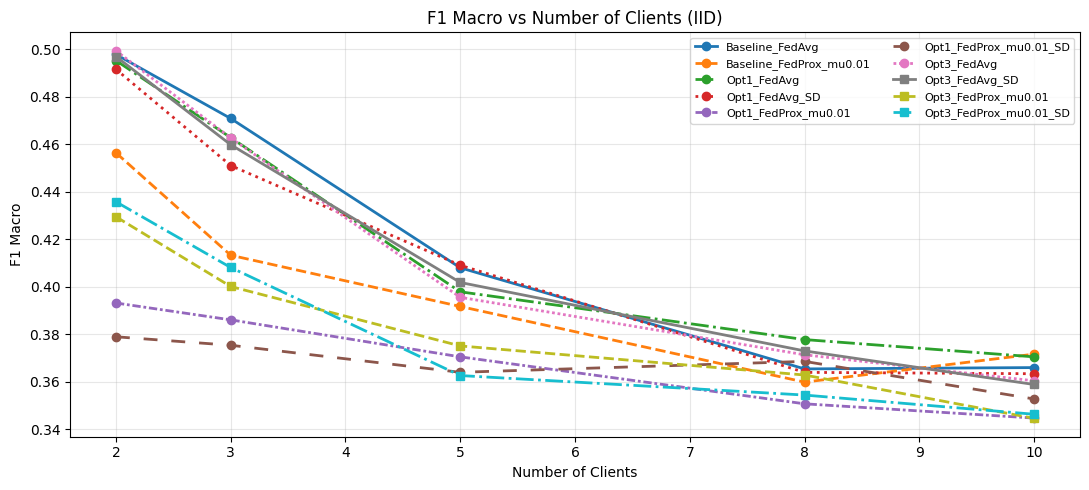

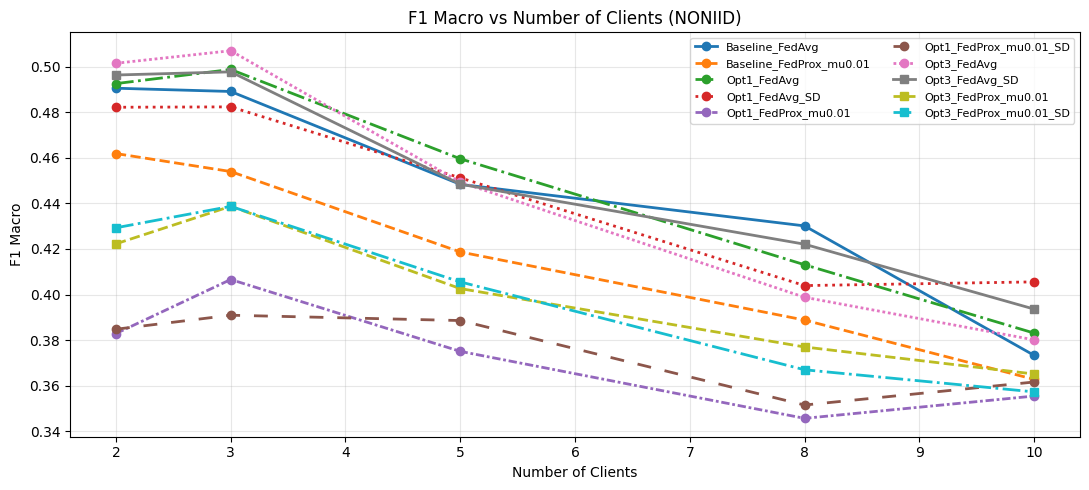

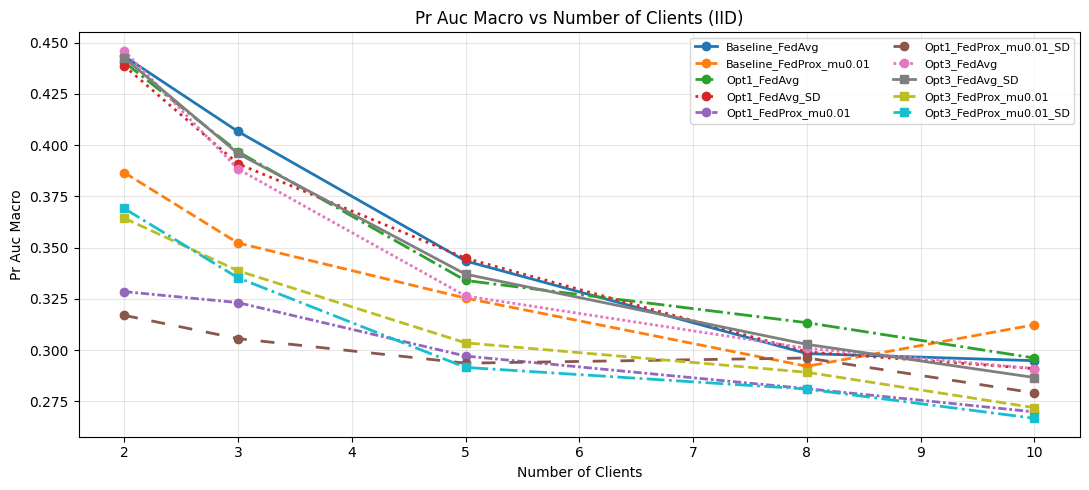

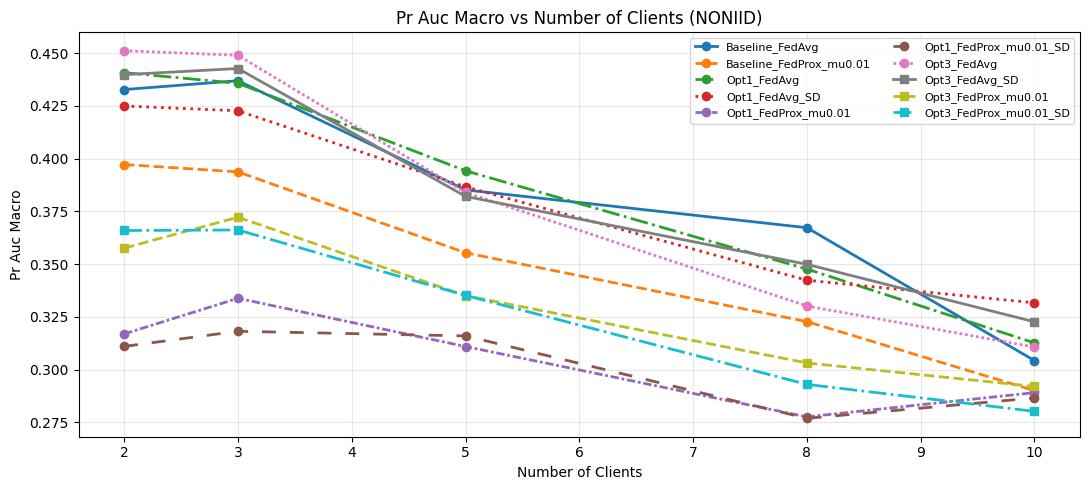

In [ ]:
# Plot Macro F1 and PR-AUC Macro

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="f1_macro", bw=False)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="f1_macro", bw=False)

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="pr_auc_macro", bw=False)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="pr_auc_macro", bw=False)

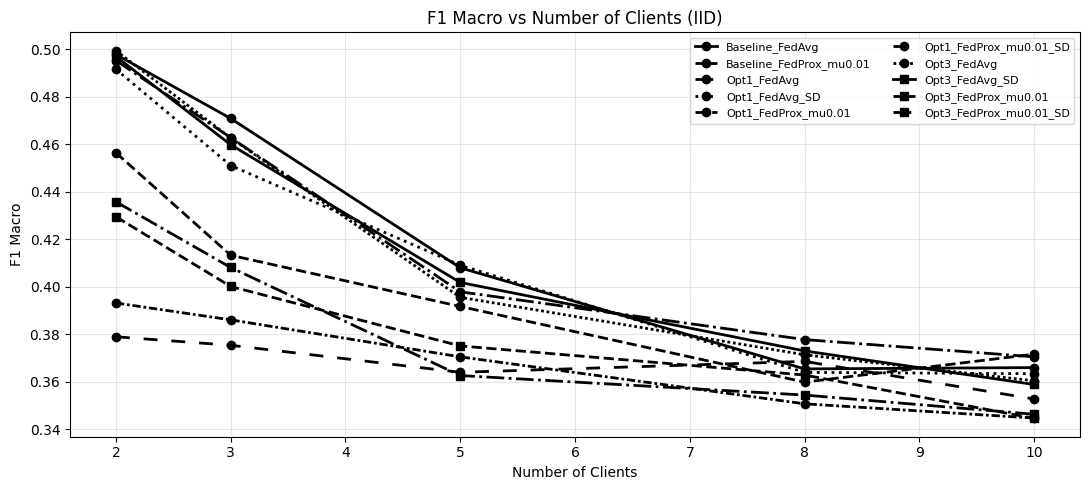

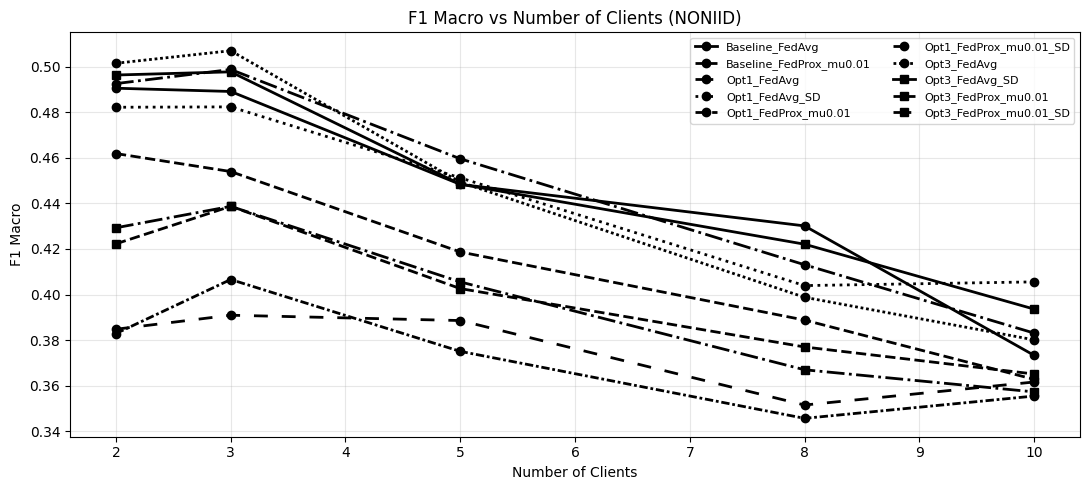

In [ ]:
# Black-and-white versions for paper drafting

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="f1_macro", bw=True)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="f1_macro", bw=True)

## Targeted Tuning Plan: Option 3 + FedAvg + Non-IID

This section performs a focused two-phase tuning study on the strongest KD setting observed so far:

- **Method:** Option 3
- **Base algorithm:** FedAvg
- **Split:** non-IID

### Phase 1
Tune the core local KD parameters:
- `kd_alpha`
- `kd_temperature`

### Phase 2
Fix the best Phase 1 setting, then tune server-side distillation:
- `server_distill_steps`
- `server_distill_lr`

This targeted approach is more efficient than tuning all methods and settings jointly,
and aligns with the current evidence that Option 3 under non-IID is the most promising configuration.

### Phase 1: Tune plain Option 3 + FedAvg + non-IID

In [ ]:
# Phase 1: tune Option 3 + FedAvg + non-IID over kd_alpha x kd_temperature

phase1_client_counts = [3, 10]   # one moderate, one harder fragmentation setting

phase1_alpha_grid = [0.3, 0.5, 0.7]
phase1_temp_grid = [1.0, 2.0, 4.0]

phase1_config = config.copy()
phase1_config["rounds"] = 10   # increase later if needed

phase1_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

#phase1_out_path = "../History/opt3_fedavg_noniid_phase1_tuning.csv"
phase1_out_path = os.path.join(KD_HISTORY_DIR, "opt3_phase1_tuning_r10_e1.csv")

In [ ]:
# # Phase 1 sweep runner with resume support

# if os.path.exists(phase1_out_path):
#     phase1_existing = pd.read_csv(phase1_out_path)
#     phase1_rows = phase1_existing.to_dict(orient="records")
#     phase1_completed = set(
#         zip(
#             phase1_existing["clients"],
#             phase1_existing["kd_alpha"],
#             phase1_existing["kd_temperature"]
#         )
#     )
#     print(f"Found existing Phase 1 results at {phase1_out_path}")
#     print(f"Loaded {len(phase1_existing)} completed rows.")
# else:
#     phase1_rows = []
#     phase1_completed = set()
#     print("No existing Phase 1 results found. Starting fresh.")

# for k in phase1_client_counts:
#     for alpha in phase1_alpha_grid:
#         for temp in phase1_temp_grid:
#             run_key = (k, alpha, temp)

#             if run_key in phase1_completed:
#                 print(f"Skipping completed Phase 1 run: K={k} | alpha={alpha} | T={temp}")
#                 continue

#             print(f"\n=== Phase 1 | Opt3 FedAvg NONIID | K={k} | alpha={alpha} | T={temp} ===")

#             try:
#                 phase1_kd_config = copy.deepcopy(kd_config)
#                 phase1_kd_config["kd_alpha"] = alpha
#                 phase1_kd_config["kd_temperature"] = temp

#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode="noniid",
#                     num_clients=k,
#                     local_epochs=1,
#                     config=phase1_config,
#                     kd_config=phase1_kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method="option3",
#                     base_algo="FedAvg",
#                     mu=0.0,
#                     server_distill=False,
#                     **phase1_noniid_params
#                 )

#                 row = {
#                     "phase": 1,
#                     "split": "noniid",
#                     "clients": k,
#                     "method_name": "Opt3_FedAvg",
#                     "method": "option3",
#                     "base_algo": "FedAvg",
#                     "server_distill": False,
#                     "mu": 0.0,

#                     "local_epochs": 1,
#                     "rounds": phase1_config["rounds"],

#                     "kd_alpha": alpha,
#                     "kd_temperature": temp,
#                     "teacher_steps_per_batch": phase1_kd_config.get("teacher_steps_per_batch", 1),

#                     "server_distill_steps": None,
#                     "server_distill_lr": None,

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),
#                     "time_sec": elapsed,

#                     "size_alpha": phase1_noniid_params["size_alpha"],
#                     "labels_per_client": phase1_noniid_params["labels_per_client"],
#                     "bias_strength": phase1_noniid_params["bias_strength"],
#                 }

#                 phase1_rows.append(row)
#                 phase1_completed.add(run_key)

#                 pd.DataFrame(phase1_rows).to_csv(phase1_out_path, index=False)
#                 print(f"Saved Phase 1 result to {phase1_out_path}")

#             except Exception as e:
#                 print(f"FAILED Phase 1: K={k} | alpha={alpha} | T={temp}")
#                 print(f"Reason: {e}")

# print(f"\nPhase 1 finished. Results saved to: {phase1_out_path}")

# phase1_df = pd.DataFrame(phase1_rows)
# display(phase1_df.head())

In [ ]:
# Load Phase 1 results

phase1_df = pd.read_csv(phase1_out_path)
print("Loaded:", phase1_out_path, "rows=", len(phase1_df))
display(phase1_df.head())

Loaded: ../History/KD/opt3_phase1_tuning_r10_e1.csv rows= 18


,phase,split,clients,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.451381,0.509590,0.831643,0.858672,0.484912,per-label,88.657723,0.5,10,0.85
1,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.448640,0.506923,0.828374,0.856859,0.476112,per-label,78.002850,0.5,10,0.85
2,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.444927,0.505434,0.825560,0.854994,0.467658,per-label,76.689054,0.5,10,0.85
3,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.448026,0.511485,0.826378,0.857479,0.478803,per-label,74.094419,0.5,10,0.85
4,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.446738,0.507019,0.826245,0.853857,0.467578,per-label,73.685797,0.5,10,0.85


In [ ]:
# Phase 1 summary tables

phase1_summary = phase1_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase1_summary)

phase1_pivot = phase1_df.pivot_table(
    index=["clients", "kd_alpha"],
    columns="kd_temperature",
    values="f1_macro"
)

display(phase1_pivot)

,phase,split,clients,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.456953,0.533012,0.831894,0.862874,0.491714,per-label,76.669199,0.5,10,0.85
1,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.444927,0.505434,0.825560,0.854994,0.467658,per-label,76.689054,0.5,10,0.85
2,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.451381,0.509590,0.831643,0.858672,0.484912,per-label,88.657723,0.5,10,0.85
3,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.446738,0.507019,0.826245,0.853857,0.467578,per-label,73.685797,0.5,10,0.85
4,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.447615,0.512918,0.828045,0.855906,0.474559,per-label,73.878521,0.5,10,0.85
5,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.448026,0.511485,0.826378,0.857479,0.478803,per-label,74.094419,0.5,10,0.85
6,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.448467,0.505227,0.829511,0.853831,0.483275,per-label,74.990395,0.5,10,0.85
7,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.448640,0.506923,0.828374,0.856859,0.476112,per-label,78.002850,0.5,10,0.85
8,1,noniid,3,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.430616,0.492639,0.816408,0.846468,0.451287,per-label,73.419979,0.5,10,0.85
9,1,noniid,10,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.314649,0.345877,0.745139,0.764759,0.366302,per-label,84.999536,0.5,10,0.85


kd_temperature         1.0       2.0       4.0
clients kd_alpha                              
3       0.3       0.506250  0.499485  0.506304
        0.5       0.501510  0.505109  0.503874
        0.7       0.492826  0.507449  0.500185
10      0.3       0.370796  0.364624  0.357481
        0.5       0.375312  0.361107  0.367963
        0.7       0.379516  0.379450  0.369953

In [ ]:
# Best Phase 1 setting per client count

phase1_best_per_k = (
    phase1_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase1_best_per_k)

,clients,phase,split,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,3,1,noniid,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.456953,0.533012,0.831894,0.862874,0.491714,per-label,76.669199,0.5,10,0.85
1,10,1,noniid,Opt3_FedAvg,option3,FedAvg,False,0.0,1,10,...,0.314649,0.345877,0.745139,0.764759,0.366302,per-label,84.999536,0.5,10,0.85


In [ ]:
# Choose one global best Phase 1 setting across the tested client counts
# Preference order: mean F1_macro, then mean PR-AUC_macro, then mean AUC_macro

phase1_global_summary = (
    phase1_df.groupby(["kd_alpha", "kd_temperature"], as_index=False)
    .agg({
        "f1_macro": "mean",
        "pr_auc_macro": "mean",
        "auc_macro": "mean",
        "time_sec": "mean"
    })
    .sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(phase1_global_summary)

best_phase1_alpha = float(phase1_global_summary.loc[0, "kd_alpha"])
best_phase1_temp = float(phase1_global_summary.loc[0, "kd_temperature"])

print(f"Best Phase 1 global setting: kd_alpha={best_phase1_alpha}, kd_temperature={best_phase1_temp}")

,kd_alpha,kd_temperature,f1_macro,pr_auc_macro,auc_macro,time_sec
0,0.7,2.0,0.443449,0.384777,0.784226,80.972670
1,0.3,1.0,0.438523,0.376257,0.783117,86.808875
2,0.5,1.0,0.438411,0.379795,0.782853,79.666953
3,0.7,1.0,0.436171,0.372632,0.780773,79.209758
4,0.5,4.0,0.435919,0.371522,0.778206,79.763794
5,0.7,4.0,0.435069,0.374395,0.783389,80.263744
6,0.5,2.0,0.433108,0.371206,0.778227,79.646785
7,0.3,2.0,0.432054,0.369616,0.778604,81.798633
8,0.3,4.0,0.431893,0.365258,0.774845,80.974561


Best Phase 1 global setting: kd_alpha=0.7, kd_temperature=2.0


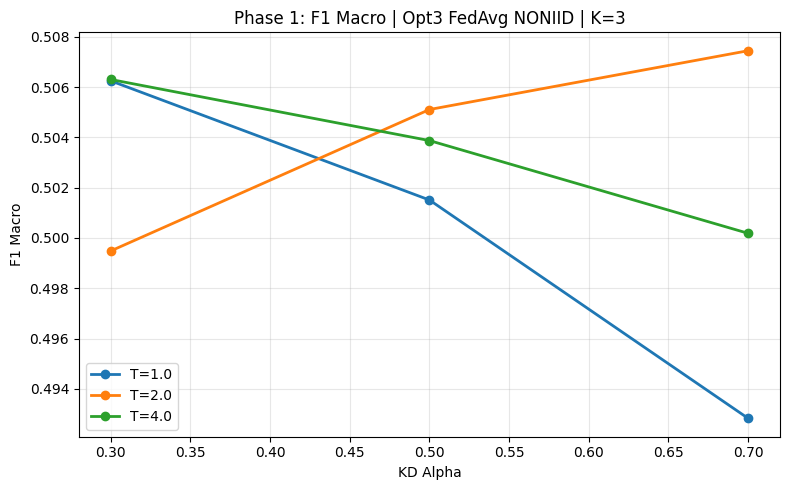

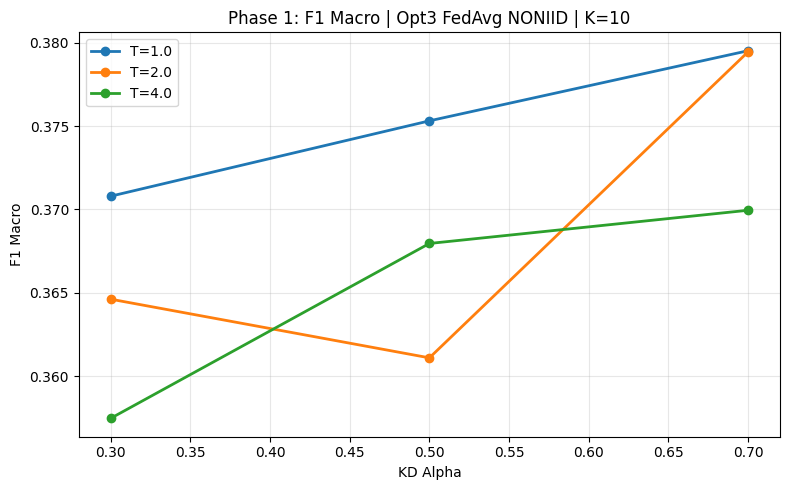

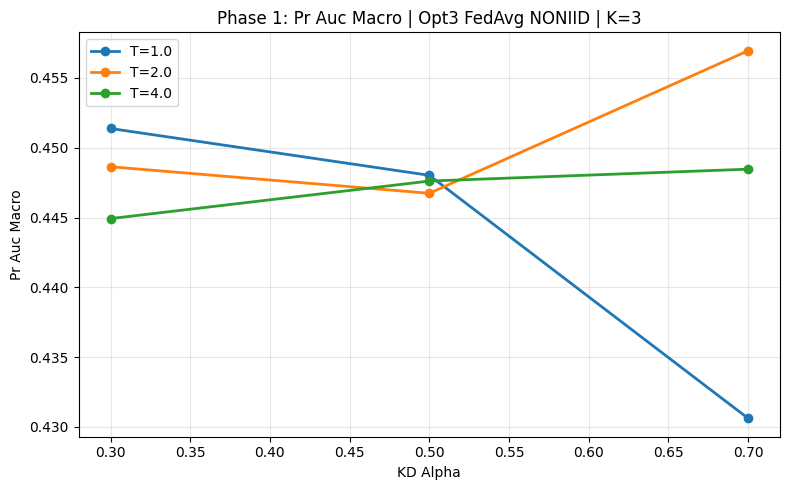

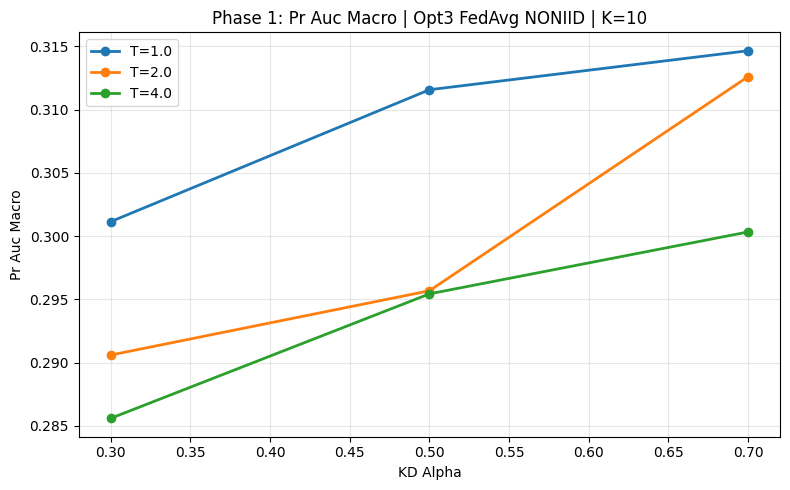

In [ ]:
# Phase 1 plotting helper

def plot_phase1_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    temps = sorted(d["kd_temperature"].unique())

    plt.figure(figsize=(8, 5))
    for temp in temps:
        g = d[d["kd_temperature"] == temp].sort_values("kd_alpha")
        plt.plot(
            g["kd_alpha"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"T={temp}"
        )

    plt.xlabel("KD Alpha")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Phase 1: {metric.replace('_', ' ').title()} | Opt3 FedAvg NONIID | K={clients_value}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase1_metric(phase1_df, clients_value=3, metric="f1_macro")
plot_phase1_metric(phase1_df, clients_value=10, metric="f1_macro")

plot_phase1_metric(phase1_df, clients_value=3, metric="pr_auc_macro")
plot_phase1_metric(phase1_df, clients_value=10, metric="pr_auc_macro")

### Phase 2: Server Distillation Tuning

Using the best Phase 1 Option 3 setting, this phase tunes:
- `server_distill_steps`
- `server_distill_lr`

The goal is to determine whether server-side refinement can improve the strongest local KD setup.

In [ ]:
# Phase 2: tune server distillation on top of best Phase 1 setting

phase2_client_counts = [3, 10]

phase2_steps_grid = [5, 10, 20]
phase2_lr_grid = [0.001, 0.002, 0.005]

phase2_config = config.copy()
phase2_config["rounds"] = 10

phase2_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

#phase2_out_path = "../History/opt3_fedavg_noniid_phase2_serverdistill_tuning.csv"
phase2_out_path = os.path.join(KD_HISTORY_DIR, "opt3_phase2_serverdistill_tuning_r10_e1.csv")

In [ ]:
# # Phase 2 sweep runner with resume support

# if os.path.exists(phase2_out_path):
#     phase2_existing = pd.read_csv(phase2_out_path)
#     phase2_rows = phase2_existing.to_dict(orient="records")
#     phase2_completed = set(
#         zip(
#             phase2_existing["clients"],
#             phase2_existing["server_distill_steps"],
#             phase2_existing["server_distill_lr"]
#         )
#     )
#     print(f"Found existing Phase 2 results at {phase2_out_path}")
#     print(f"Loaded {len(phase2_existing)} completed rows.")
# else:
#     phase2_rows = []
#     phase2_completed = set()
#     print("No existing Phase 2 results found. Starting fresh.")

# for k in phase2_client_counts:
#     for sd_steps in phase2_steps_grid:
#         for sd_lr in phase2_lr_grid:
#             run_key = (k, sd_steps, sd_lr)

#             if run_key in phase2_completed:
#                 print(f"Skipping completed Phase 2 run: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
#                 continue

#             print(
#                 f"\n=== Phase 2 | Opt3 FedAvg NONIID + SD | "
#                 f"K={k} | alpha={best_phase1_alpha} | T={best_phase1_temp} | "
#                 f"SD_steps={sd_steps} | SD_lr={sd_lr} ==="
#             )

#             try:
#                 phase2_kd_config = copy.deepcopy(kd_config)
#                 phase2_kd_config["kd_alpha"] = best_phase1_alpha
#                 phase2_kd_config["kd_temperature"] = best_phase1_temp
#                 phase2_kd_config["server_distill_steps"] = sd_steps
#                 phase2_kd_config["server_distill_lr"] = sd_lr

#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode="noniid",
#                     num_clients=k,
#                     local_epochs=1,
#                     config=phase2_config,
#                     kd_config=phase2_kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method="option3",
#                     base_algo="FedAvg",
#                     mu=0.0,
#                     server_distill=True,
#                     **phase2_noniid_params
#                 )

#                 row = {
#                     "phase": 2,
#                     "split": "noniid",
#                     "clients": k,
#                     "method_name": "Opt3_FedAvg_SD",
#                     "method": "option3",
#                     "base_algo": "FedAvg",
#                     "server_distill": True,
#                     "mu": 0.0,

#                     "local_epochs": 1,
#                     "rounds": phase2_config["rounds"],

#                     "kd_alpha": best_phase1_alpha,
#                     "kd_temperature": best_phase1_temp,
#                     "teacher_steps_per_batch": phase2_kd_config.get("teacher_steps_per_batch", 1),

#                     "server_distill_steps": sd_steps,
#                     "server_distill_lr": sd_lr,

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),
#                     "time_sec": elapsed,

#                     "size_alpha": phase2_noniid_params["size_alpha"],
#                     "labels_per_client": phase2_noniid_params["labels_per_client"],
#                     "bias_strength": phase2_noniid_params["bias_strength"],
#                 }

#                 phase2_rows.append(row)
#                 phase2_completed.add(run_key)

#                 pd.DataFrame(phase2_rows).to_csv(phase2_out_path, index=False)
#                 print(f"Saved Phase 2 result to {phase2_out_path}")

#             except Exception as e:
#                 print(f"FAILED Phase 2: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
#                 print(f"Reason: {e}")

# print(f"\nPhase 2 finished. Results saved to: {phase2_out_path}")

# phase2_df = pd.DataFrame(phase2_rows)
# display(phase2_df.head())

In [ ]:
# Load Phase 2 results

phase2_df = pd.read_csv(phase2_out_path)
print("Loaded:", phase2_out_path, "rows=", len(phase2_df))
display(phase2_df.head())

Loaded: ../History/KD/opt3_phase2_serverdistill_tuning_r10_e1.csv rows= 18


,phase,split,clients,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.451044,0.496661,0.825862,0.850789,0.484287,per-label,100.303066,0.5,10,0.85
1,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.450392,0.504562,0.828409,0.853166,0.469265,per-label,101.211627,0.5,10,0.85
2,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.428682,0.491759,0.817376,0.845976,0.462190,per-label,101.732257,0.5,10,0.85
3,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.442100,0.509522,0.824965,0.853276,0.474814,per-label,104.807041,0.5,10,0.85
4,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.435292,0.499203,0.816829,0.847851,0.465974,per-label,105.667986,0.5,10,0.85


In [ ]:
# Phase 2 summary tables

phase2_summary = phase2_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase2_summary)

phase2_pivot = phase2_df.pivot_table(
    index=["clients", "server_distill_steps"],
    columns="server_distill_lr",
    values="f1_macro"
)

display(phase2_pivot)

,phase,split,clients,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.450918,0.509162,0.829330,0.854024,0.465104,per-label,110.168997,0.5,10,0.85
1,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.450392,0.504562,0.828409,0.853166,0.469265,per-label,101.211627,0.5,10,0.85
2,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.442100,0.509522,0.824965,0.853276,0.474814,per-label,104.807041,0.5,10,0.85
3,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.451044,0.496661,0.825862,0.850789,0.484287,per-label,100.303066,0.5,10,0.85
4,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.433754,0.495139,0.818979,0.847643,0.458632,per-label,110.690464,0.5,10,0.85
5,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.435292,0.499203,0.816829,0.847851,0.465974,per-label,105.667986,0.5,10,0.85
6,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.434496,0.487788,0.816520,0.846067,0.463878,per-label,104.738101,0.5,10,0.85
7,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.427634,0.485623,0.816857,0.844195,0.460043,per-label,110.432202,0.5,10,0.85
8,2,noniid,3,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.428682,0.491759,0.817376,0.845976,0.462190,per-label,101.732257,0.5,10,0.85
9,2,noniid,10,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.320740,0.356543,0.745487,0.772698,0.366602,per-label,180.949071,0.5,10,0.85


server_distill_lr                0.001     0.002     0.005
clients server_distill_steps                              
3       5                     0.500145  0.504812  0.484060
        10                    0.503061  0.496082  0.492748
        20                    0.507494  0.498178  0.487613
10      5                     0.379638  0.395052  0.393922
        10                    0.378925  0.393677  0.383721
        20                    0.382357  0.386655  0.386870

In [ ]:
# Best Phase 2 setting per client count

phase2_best_per_k = (
    phase2_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase2_best_per_k)

,clients,phase,split,method_name,method,base_algo,server_distill,mu,local_epochs,rounds,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,3,2,noniid,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.450918,0.509162,0.829330,0.854024,0.465104,per-label,110.168997,0.5,10,0.85
1,10,2,noniid,Opt3_FedAvg_SD,option3,FedAvg,True,0.0,1,10,...,0.320740,0.356543,0.745487,0.772698,0.366602,per-label,180.949071,0.5,10,0.85


In [ ]:
# Compare best Phase 2 SD settings against best non-SD Phase 1 setting

phase1_best_compare = phase1_best_per_k[[
    "clients", "kd_alpha", "kd_temperature",
    "f1_macro", "pr_auc_macro", "auc_macro", "time_sec"
]].copy()
phase1_best_compare["variant"] = "Opt3_FedAvg_Best_Phase1"

phase2_best_compare = phase2_best_per_k[[
    "clients", "server_distill_steps", "server_distill_lr",
    "f1_macro", "pr_auc_macro", "auc_macro", "time_sec"
]].copy()
phase2_best_compare["variant"] = "Opt3_FedAvg_SD_Best_Phase2"

display(phase1_best_compare)
display(phase2_best_compare)

,clients,kd_alpha,kd_temperature,f1_macro,pr_auc_macro,auc_macro,time_sec,variant
0,3,0.7,2.0,0.507449,0.456953,0.831894,76.669199,Opt3_FedAvg_Best_Phase1
1,10,0.7,1.0,0.379516,0.314649,0.745139,84.999536,Opt3_FedAvg_Best_Phase1


,clients,server_distill_steps,server_distill_lr,f1_macro,pr_auc_macro,auc_macro,time_sec,variant
0,3,20,0.001,0.507494,0.450918,0.829330,110.168997,Opt3_FedAvg_SD_Best_Phase2
1,10,5,0.002,0.395052,0.320740,0.745487,180.949071,Opt3_FedAvg_SD_Best_Phase2


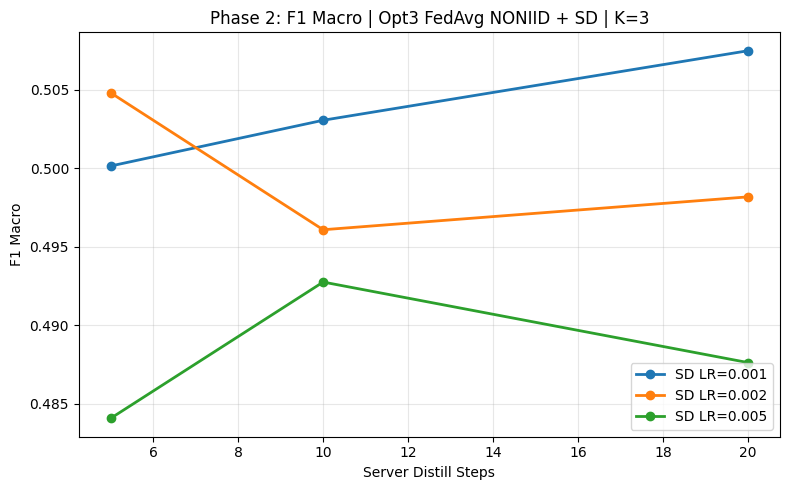

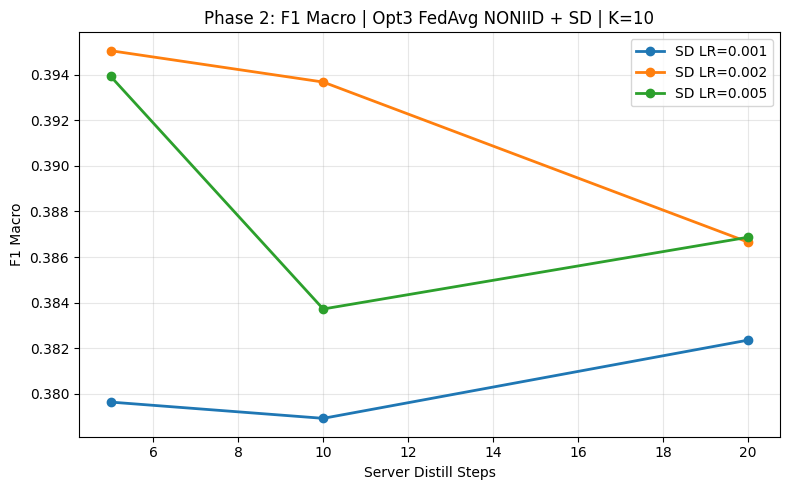

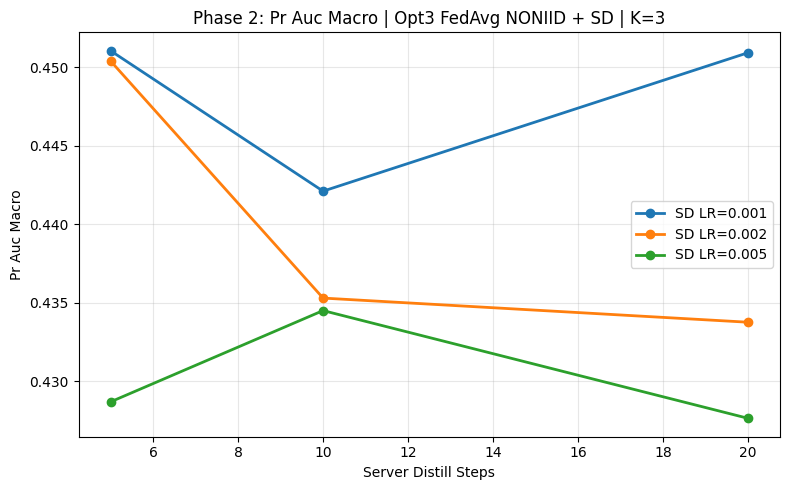

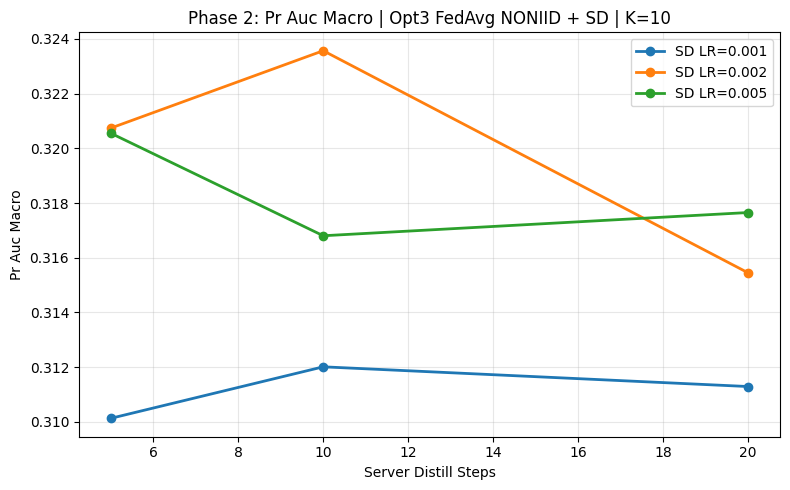

In [ ]:
# Phase 2 plotting helper

def plot_phase2_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    lrs = sorted(d["server_distill_lr"].unique())

    plt.figure(figsize=(8, 5))
    for sd_lr in lrs:
        g = d[d["server_distill_lr"] == sd_lr].sort_values("server_distill_steps")
        plt.plot(
            g["server_distill_steps"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"SD LR={sd_lr}"
        )

    plt.xlabel("Server Distill Steps")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(
        f"Phase 2: {metric.replace('_', ' ').title()} | "
        f"Opt3 FedAvg NONIID + SD | K={clients_value}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase2_metric(phase2_df, clients_value=3, metric="f1_macro")
plot_phase2_metric(phase2_df, clients_value=10, metric="f1_macro")

plot_phase2_metric(phase2_df, clients_value=3, metric="pr_auc_macro")
plot_phase2_metric(phase2_df, clients_value=10, metric="pr_auc_macro")

In [ ]:
# Final combined comparison: best non-SD vs best SD settings

final_compare = []

for k in sorted(set(phase1_best_per_k["clients"]).intersection(set(phase2_best_per_k["clients"]))):
    p1 = phase1_best_per_k[phase1_best_per_k["clients"] == k].iloc[0]
    p2 = phase2_best_per_k[phase2_best_per_k["clients"] == k].iloc[0]

    final_compare.append({
        "clients": k,

        "best_phase1_alpha": p1["kd_alpha"],
        "best_phase1_temp": p1["kd_temperature"],
        "phase1_f1_macro": p1["f1_macro"],
        "phase1_pr_auc_macro": p1["pr_auc_macro"],
        "phase1_auc_macro": p1["auc_macro"],

        "best_phase2_sd_steps": p2["server_distill_steps"],
        "best_phase2_sd_lr": p2["server_distill_lr"],
        "phase2_f1_macro": p2["f1_macro"],
        "phase2_pr_auc_macro": p2["pr_auc_macro"],
        "phase2_auc_macro": p2["auc_macro"],

        "delta_f1_macro": p2["f1_macro"] - p1["f1_macro"],
        "delta_pr_auc_macro": p2["pr_auc_macro"] - p1["pr_auc_macro"],
        "delta_auc_macro": p2["auc_macro"] - p1["auc_macro"],
    })

final_compare_df = pd.DataFrame(final_compare)
display(final_compare_df)

,clients,best_phase1_alpha,best_phase1_temp,phase1_f1_macro,phase1_pr_auc_macro,phase1_auc_macro,best_phase2_sd_steps,best_phase2_sd_lr,phase2_f1_macro,phase2_pr_auc_macro,phase2_auc_macro,delta_f1_macro,delta_pr_auc_macro,delta_auc_macro
0,3,0.7,2.0,0.507449,0.456953,0.831894,20,0.001,0.507494,0.450918,0.829330,0.000045,-0.006035,-0.002565
1,10,0.7,1.0,0.379516,0.314649,0.745139,5,0.002,0.395052,0.320740,0.745487,0.015536,0.006091,0.000348


## Final Focused Sweep: Tuned Option 3 under Non-IID

This section runs a focused final comparison under the setting where KD was most effective:
- non-IID split
- FedAvg base algorithm
- tuned Option 3 local KD

Methods compared:
- Baseline FedAvg
- Tuned Option 3 + FedAvg
- Tuned Option 3 + FedAvg + Server Distillation

Tuned Option 3 parameters from Phase 1:
- kd_alpha = 0.7
- kd_temperature = 2.0

Server distillation parameters from Phase 2:
- server_distill_steps = 5
- server_distill_lr = 0.002

In [ ]:
final_client_counts = [2, 3, 4, 8, 10, 12, 15, 20]

final_config = config.copy()
final_config["rounds"] = 100
final_local_epochs = 3

final_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

final_opt3_kd_config = copy.deepcopy(kd_config)
final_opt3_kd_config["kd_alpha"] = 0.7
final_opt3_kd_config["kd_temperature"] = 2.0
final_opt3_kd_config["server_distill_steps"] = 5
final_opt3_kd_config["server_distill_lr"] = 0.002

FINAL_METHODS = [
    dict(method_name="Baseline_FedAvg",        method="baseline", base_algo="FedAvg", mu=0.0, server_distill=False),
    dict(method_name="Opt3_FedAvg_Tuned",      method="option3",  base_algo="FedAvg", mu=0.0, server_distill=False),
    dict(method_name="Opt3_FedAvg_Tuned_SD",   method="option3",  base_algo="FedAvg", mu=0.0, server_distill=True),
]

final_opt3_out_path = os.path.join(KD_HISTORY_DIR, "final_opt3_noniid_sweep_r100_e3.csv")

In [ ]:
# # Focused sweep runner with resume support

# if os.path.exists(final_opt3_out_path):
#     final_existing = pd.read_csv(final_opt3_out_path)
#     final_rows = final_existing.to_dict(orient="records")
#     final_completed = set(
#         zip(
#             final_existing["method_name"],
#             final_existing["clients"]
#         )
#     )
#     print(f"Found existing results at {final_opt3_out_path}")
#     print(f"Loaded {len(final_existing)} completed rows.")
# else:
#     final_rows = []
#     final_completed = set()
#     print("No existing focused sweep results found. Starting fresh.")

# for m in FINAL_METHODS:
#     for k in final_client_counts:
#         run_key = (m["method_name"], k)

#         if run_key in final_completed:
#             print(f"Skipping completed run: {m['method_name']} | K={k}")
#             continue

#         print(f"\n=== FINAL NONIID | {m['method_name']} | K={k} ===")

#         try:
#             metrics, elapsed = run_fl_kd_once(
#                 split_mode="noniid",
#                 num_clients=k,
#                 local_epochs=final_local_epochs,
#                 config=final_config,
#                 kd_config=final_opt3_kd_config,
#                 train_dataset=train_dataset,
#                 val_loader=val_loader,
#                 test_loader=test_loader,
#                 device=device,
#                 seed=42,
#                 method=m["method"],
#                 base_algo=m["base_algo"],
#                 mu=m["mu"],
#                 server_distill=m["server_distill"],
#                 **final_noniid_params
#             )

#             row = {
#                 "split": "noniid",
#                 "clients": k,

#                 "method_name": m["method_name"],
#                 "method": m["method"],
#                 "base_algo": m["base_algo"],
#                 "mu": m["mu"],
#                 "server_distill": m["server_distill"],

#                 "local_epochs": final_local_epochs,
#                 "rounds": final_config["rounds"],

#                 "kd_alpha": final_opt3_kd_config["kd_alpha"],
#                 "kd_temperature": final_opt3_kd_config["kd_temperature"],
#                 "server_distill_steps": final_opt3_kd_config["server_distill_steps"] if m["server_distill"] else None,
#                 "server_distill_lr": final_opt3_kd_config["server_distill_lr"] if m["server_distill"] else None,

#                 "f1_macro": metrics.get("f1_macro"),
#                 "f1_micro": metrics.get("f1_micro"),
#                 "pr_auc_macro": metrics.get("pr_auc_macro"),
#                 "pr_auc_micro": metrics.get("pr_auc_micro"),
#                 "auc_macro": metrics.get("auc_macro"),
#                 "auc_micro": metrics.get("auc_micro"),
#                 "best_f1_micro": metrics.get("best_f1_micro"),
#                 "best_thr": metrics.get("best_thr"),

#                 "time_sec": elapsed,

#                 "size_alpha": final_noniid_params["size_alpha"],
#                 "labels_per_client": final_noniid_params["labels_per_client"],
#                 "bias_strength": final_noniid_params["bias_strength"],
#             }

#             final_rows.append(row)
#             final_completed.add(run_key)

#             pd.DataFrame(final_rows).to_csv(final_opt3_out_path, index=False)
#             print(f"Saved result to {final_opt3_out_path}")

#         except Exception as e:
#             print(f"FAILED: {m['method_name']} | K={k}")
#             print(f"Reason: {e}")

# print(f"\nFocused sweep finished. Results saved to: {final_opt3_out_path}")

# final_opt3_df = pd.DataFrame(final_rows)
# display(final_opt3_df.head())

In [ ]:
final_opt3_df = pd.read_csv(final_opt3_out_path)
print("Loaded:", final_opt3_out_path, "rows=", len(final_opt3_df))
display(final_opt3_df)

Loaded: ../History/KD/final_opt3_noniid_sweep_r100_e3.csv rows= 24


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,noniid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.592305,0.645713,0.902099,0.918899,0.638769,per-label,227.477437,0.5,10,0.85
1,noniid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.586284,0.634925,0.898842,0.915307,0.616687,per-label,212.322955,0.5,10,0.85
2,noniid,4,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.585145,0.638166,0.899383,0.916518,0.625644,per-label,212.509935,0.5,10,0.85
3,noniid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.587105,0.643985,0.897471,0.917300,0.619431,per-label,215.664194,0.5,10,0.85
4,noniid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.570037,0.623387,0.892800,0.911395,0.602419,per-label,217.614688,0.5,10,0.85
5,noniid,12,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.561718,0.603689,0.887321,0.906250,0.586187,per-label,219.968388,0.5,10,0.85
6,noniid,15,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.546792,0.592691,0.880665,0.901291,0.577665,per-label,218.765876,0.5,10,0.85
7,noniid,20,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.551331,0.597874,0.883849,0.902616,0.584014,per-label,221.614663,0.5,10,0.85
8,noniid,2,Opt3_FedAvg_Tuned,option3,FedAvg,0.0,False,3,100,0.7,...,0.600881,0.652491,0.904702,0.920872,0.651686,per-label,512.008104,0.5,10,0.85
9,noniid,3,Opt3_FedAvg_Tuned,option3,FedAvg,0.0,False,3,100,0.7,...,0.603577,0.656371,0.904081,0.922254,0.639327,per-label,514.900201,0.5,10,0.85


In [ ]:
final_opt3_pivot = final_opt3_df.pivot_table(
    index="clients",
    columns="method_name",
    values="f1_macro"
)
display(final_opt3_pivot)

method_name,Baseline_FedAvg,Opt3_FedAvg_Tuned,Opt3_FedAvg_Tuned_SD
clients,,,
2,0.614526,0.622915,0.628322
3,0.611010,0.628490,0.606778
4,0.618236,0.617808,0.617208
8,0.614141,0.614492,0.604108
10,0.606036,0.590331,0.596804
12,0.593678,0.602978,0.599638
15,0.582258,0.601443,0.605782
20,0.584479,0.591364,0.606884


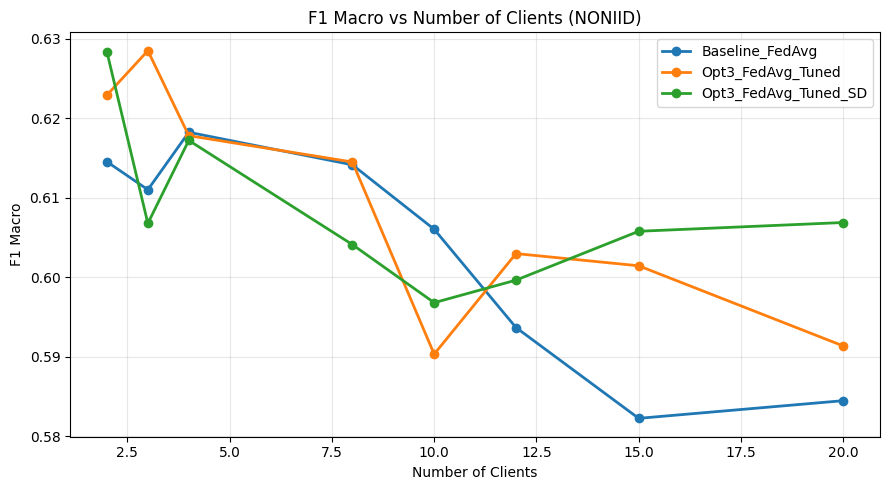

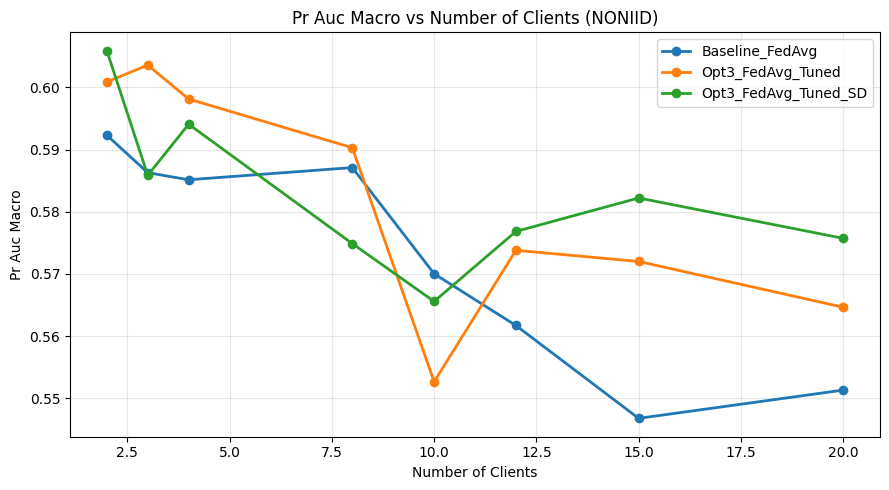

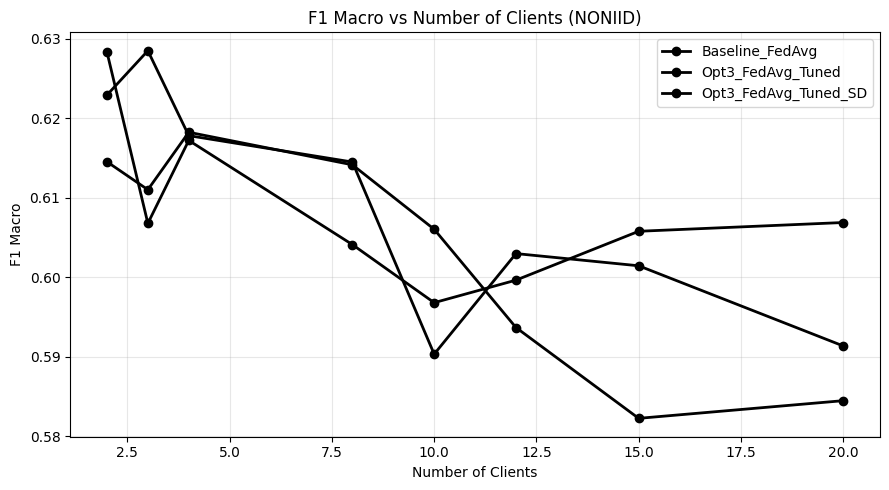

In [ ]:
def plot_final_opt3_metric(df, metric="f1_macro", bw=False):
    methods = [
        "Baseline_FedAvg",
        "Opt3_FedAvg_Tuned",
        "Opt3_FedAvg_Tuned_SD"
    ]

    plt.figure(figsize=(9, 5))

    for method in methods:
        g = df[df["method_name"] == method].sort_values("clients")

        if bw:
            plt.plot(
                g["clients"], g[metric],
                color="black",
                marker="o",
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g[metric],
                marker="o",
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients (NONIID)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_final_opt3_metric(final_opt3_df, metric="f1_macro", bw=False)
plot_final_opt3_metric(final_opt3_df, metric="pr_auc_macro", bw=False)
plot_final_opt3_metric(final_opt3_df, metric="f1_macro", bw=True)

## Final Focused Sweep: Tuned Option 3 under IID

This section runs the IID counterpart to the final non-IID sweep, using the same
tuned Option 3 configuration. The goal is to test whether KD remains beneficial
when client heterogeneity is removed.

In [ ]:
# New config cell for IID-only final sweep

final_client_counts = [2, 3, 4, 8, 10, 12, 15, 20]
final_split_mode = "iid"

final_config = config.copy()
final_config["rounds"] = 100
final_local_epochs = 3

final_opt3_kd_config = copy.deepcopy(kd_config)
final_opt3_kd_config["kd_alpha"] = 0.7
final_opt3_kd_config["kd_temperature"] = 2.0
final_opt3_kd_config["server_distill_steps"] = 5
final_opt3_kd_config["server_distill_lr"] = 0.002

FINAL_METHODS = [
    dict(method_name="Baseline_FedAvg",        method="baseline", base_algo="FedAvg", mu=0.0, server_distill=False),
    dict(method_name="Opt3_FedAvg_Tuned",      method="option3",  base_algo="FedAvg", mu=0.0, server_distill=False),
    dict(method_name="Opt3_FedAvg_Tuned_SD",   method="option3",  base_algo="FedAvg", mu=0.0, server_distill=True),
]

final_opt3_iid_out_path = os.path.join(KD_HISTORY_DIR, "final_opt3_iid_sweep_r100_e3.csv")

In [76]:
# IID-only focused sweep runner with resume support

if os.path.exists(final_opt3_iid_out_path):
    final_existing = pd.read_csv(final_opt3_iid_out_path)
    final_rows = final_existing.to_dict(orient="records")
    final_completed = set(
        zip(
            final_existing["method_name"],
            final_existing["clients"]
        )
    )
    print(f"Found existing IID results at {final_opt3_iid_out_path}")
    print(f"Loaded {len(final_existing)} completed rows.")
else:
    final_rows = []
    final_completed = set()
    print("No existing IID focused sweep results found. Starting fresh.")

for m in FINAL_METHODS:
    for k in final_client_counts:
        run_key = (m["method_name"], k)

        if run_key in final_completed:
            print(f"Skipping completed run: {m['method_name']} | K={k}")
            continue

        print(f"\n=== FINAL IID | {m['method_name']} | K={k} ===")

        try:
            metrics, elapsed = run_fl_kd_once(
                split_mode=final_split_mode,
                num_clients=k,
                local_epochs=final_local_epochs,
                config=final_config,
                kd_config=final_opt3_kd_config,
                train_dataset=train_dataset,
                val_loader=val_loader,
                test_loader=test_loader,
                device=device,
                seed=42,
                method=m["method"],
                base_algo=m["base_algo"],
                mu=m["mu"],
                server_distill=m["server_distill"]
            )

            row = {
                "split": final_split_mode,
                "clients": k,

                "method_name": m["method_name"],
                "method": m["method"],
                "base_algo": m["base_algo"],
                "mu": m["mu"],
                "server_distill": m["server_distill"],

                "local_epochs": final_local_epochs,
                "rounds": final_config["rounds"],

                "kd_alpha": final_opt3_kd_config["kd_alpha"],
                "kd_temperature": final_opt3_kd_config["kd_temperature"],
                "server_distill_steps": final_opt3_kd_config["server_distill_steps"] if m["server_distill"] else None,
                "server_distill_lr": final_opt3_kd_config["server_distill_lr"] if m["server_distill"] else None,

                "f1_macro": metrics.get("f1_macro"),
                "f1_micro": metrics.get("f1_micro"),
                "pr_auc_macro": metrics.get("pr_auc_macro"),
                "pr_auc_micro": metrics.get("pr_auc_micro"),
                "auc_macro": metrics.get("auc_macro"),
                "auc_micro": metrics.get("auc_micro"),
                "best_f1_micro": metrics.get("best_f1_micro"),
                "best_thr": metrics.get("best_thr"),

                "time_sec": elapsed,
            }

            final_rows.append(row)
            final_completed.add(run_key)

            pd.DataFrame(final_rows).to_csv(final_opt3_iid_out_path, index=False)
            print(f"Saved result to {final_opt3_iid_out_path}")

        except Exception as e:
            print(f"FAILED: {m['method_name']} | K={k}")
            print(f"Reason: {e}")

print(f"\nIID focused sweep finished. Results saved to: {final_opt3_iid_out_path}")

final_opt3_iid_df = pd.DataFrame(final_rows)
display(final_opt3_iid_df.head())

Found existing IID results at ../History/KD/final_opt3_iid_sweep_r100_e3.csv
Loaded 12 completed rows.
Skipping completed run: Baseline_FedAvg | K=2
Skipping completed run: Baseline_FedAvg | K=3
Skipping completed run: Baseline_FedAvg | K=4
Skipping completed run: Baseline_FedAvg | K=8
Skipping completed run: Baseline_FedAvg | K=10
Skipping completed run: Baseline_FedAvg | K=12
Skipping completed run: Baseline_FedAvg | K=15
Skipping completed run: Baseline_FedAvg | K=20
Skipping completed run: Opt3_FedAvg_Tuned | K=2
Skipping completed run: Opt3_FedAvg_Tuned | K=3
Skipping completed run: Opt3_FedAvg_Tuned | K=4
Skipping completed run: Opt3_FedAvg_Tuned | K=8

=== FINAL IID | Opt3_FedAvg_Tuned | K=10 ===


option3 | FedAvg | iid | K=10 | E=3: 100%|██████████| 100/100 [08:40<00:00,  5.20s/it]


[Per-Label Thresholds] Macro F1=0.5762
[Eval] Avg loss=0.3687 | F1_micro=0.6014 | F1_macro=0.5971 | AUC_macro=0.8890 | AUC_micro=0.9125 | PR-AUC_macro=0.5639 | PR-AUC_micro=0.6262 | Best_F1=0.6014 @ thr=per-label | Avg labels/sample=8.14
Saved result to ../History/KD/final_opt3_iid_sweep_r100_e3.csv

=== FINAL IID | Opt3_FedAvg_Tuned | K=12 ===


option3 | FedAvg | iid | K=12 | E=3: 100%|██████████| 100/100 [08:21<00:00,  5.01s/it]


[Per-Label Thresholds] Macro F1=0.5687
[Eval] Avg loss=0.3686 | F1_micro=0.5868 | F1_macro=0.5785 | AUC_macro=0.8817 | AUC_micro=0.9061 | PR-AUC_macro=0.5525 | PR-AUC_micro=0.6145 | Best_F1=0.5868 @ thr=per-label | Avg labels/sample=8.22
Saved result to ../History/KD/final_opt3_iid_sweep_r100_e3.csv

=== FINAL IID | Opt3_FedAvg_Tuned | K=15 ===


...

[Per-Label Thresholds] Macro F1=0.5650
[Eval] Avg loss=0.3608 | F1_micro=0.5844 | F1_macro=0.5888 | AUC_macro=0.8829 | AUC_micro=0.9075 | PR-AUC_macro=0.5515 | PR-AUC_micro=0.6159 | Best_F1=0.5844 @ thr=per-label | Avg labels/sample=8.88
Saved result to ../History/KD/final_opt3_iid_sweep_r100_e3.csv

=== FINAL IID | Opt3_FedAvg_Tuned_SD | K=20 ===


option3 | FedAvg + SD | iid | K=20 | E=3: 100%|██████████| 100/100 [58:37<00:00, 35.18s/it]


[Per-Label Thresholds] Macro F1=0.5437
[Eval] Avg loss=0.3912 | F1_micro=0.5559 | F1_macro=0.5592 | AUC_macro=0.8639 | AUC_micro=0.8947 | PR-AUC_macro=0.5237 | PR-AUC_micro=0.5922 | Best_F1=0.5559 @ thr=per-label | Avg labels/sample=8.86
Saved result to ../History/KD/final_opt3_iid_sweep_r100_e3.csv

IID focused sweep finished. Results saved to: ../History/KD/final_opt3_iid_sweep_r100_e3.csv


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,server_distill_lr,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.620346,0.629098,0.594201,0.647317,0.902209,0.919055,0.629098,per-label,209.499002
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.620256,0.636654,0.596996,0.647961,0.902689,0.919226,0.636654,per-label,212.028694
2,iid,4,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.623579,0.635661,0.599839,0.651779,0.902924,0.920362,0.635661,per-label,212.538483
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.618911,0.624013,0.596664,0.654570,0.900414,0.919235,0.624013,per-label,217.224556
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.610876,0.608158,0.581805,0.638298,0.894814,0.915349,0.608158,per-label,220.758349


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [77]:
# Load and inspect IID results

final_opt3_iid_df = pd.read_csv(final_opt3_iid_out_path)
print("Loaded:", final_opt3_iid_out_path, "rows=", len(final_opt3_iid_df))
display(final_opt3_iid_df)

final_opt3_iid_pivot = final_opt3_iid_df.pivot_table(
    index="clients",
    columns="method_name",
    values="f1_macro"
)
display(final_opt3_iid_pivot)

Loaded: ../History/KD/final_opt3_iid_sweep_r100_e3.csv rows= 24


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,server_distill_lr,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.620346,0.629098,0.594201,0.647317,0.902209,0.919055,0.629098,per-label,209.499002
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.620256,0.636654,0.596996,0.647961,0.902689,0.919226,0.636654,per-label,212.028694
2,iid,4,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.623579,0.635661,0.599839,0.651779,0.902924,0.920362,0.635661,per-label,212.538483
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.618911,0.624013,0.596664,0.654570,0.900414,0.919235,0.624013,per-label,217.224556
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.610876,0.608158,0.581805,0.638298,0.894814,0.915349,0.608158,per-label,220.758349
5,iid,12,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.600069,0.595023,0.569423,0.621862,0.889100,0.910687,0.595023,per-label,214.407477
6,iid,15,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.607174,0.599629,0.577390,0.635309,0.892906,0.913387,0.599629,per-label,219.463583
7,iid,20,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,NaN,0.578370,0.568527,0.542704,0.609416,0.873264,0.900393,0.568527,per-label,229.797459
8,iid,2,Opt3_FedAvg_Tuned,option3,FedAvg,0.0,False,3,100,0.7,...,NaN,0.627119,0.629465,0.602568,0.654168,0.904574,0.922200,0.629465,per-label,510.295792
9,iid,3,Opt3_FedAvg_Tuned,option3,FedAvg,0.0,False,3,100,0.7,...,NaN,0.623625,0.627488,0.600737,0.652927,0.902558,0.920498,0.627488,per-label,511.616097


method_name,Baseline_FedAvg,Opt3_FedAvg_Tuned,Opt3_FedAvg_Tuned_SD
clients,,,
2,0.620346,0.627119,0.623892
3,0.620256,0.623625,0.621364
4,0.623579,0.620270,0.625501
8,0.618911,0.609212,0.594450
10,0.610876,0.597071,0.608608
12,0.600069,0.578523,0.588242
15,0.607174,0.587217,0.588764
20,0.578370,0.576876,0.559241


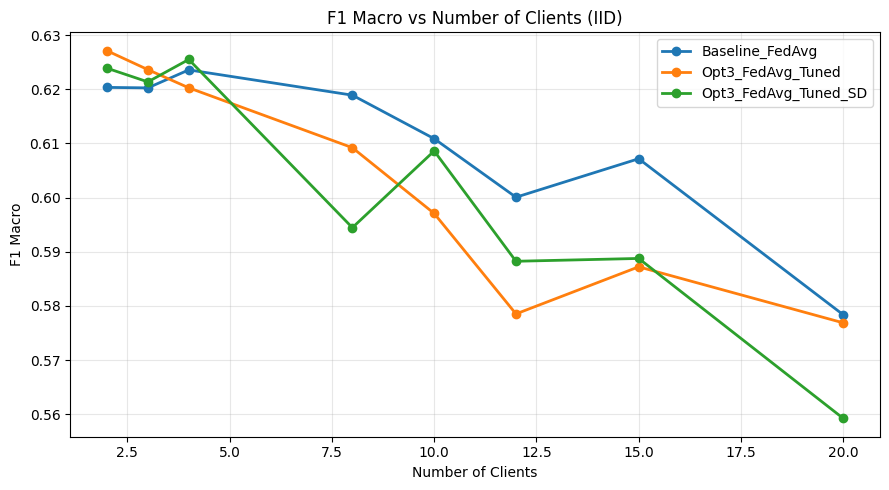

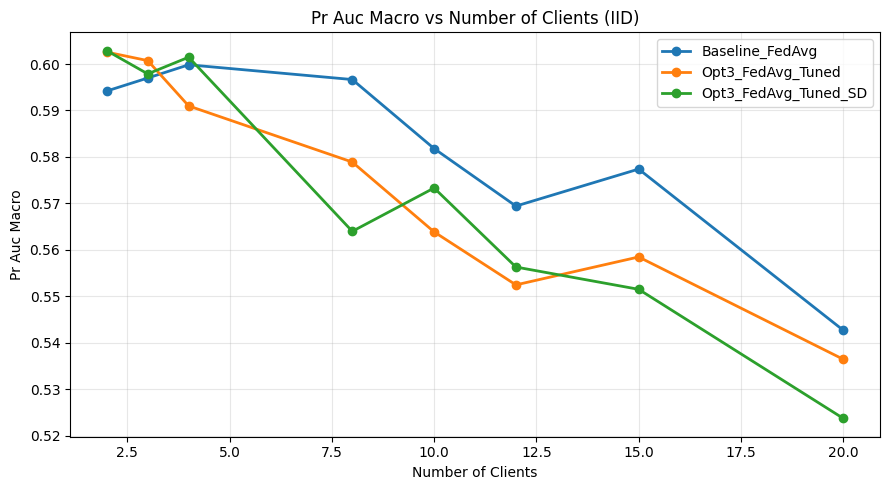

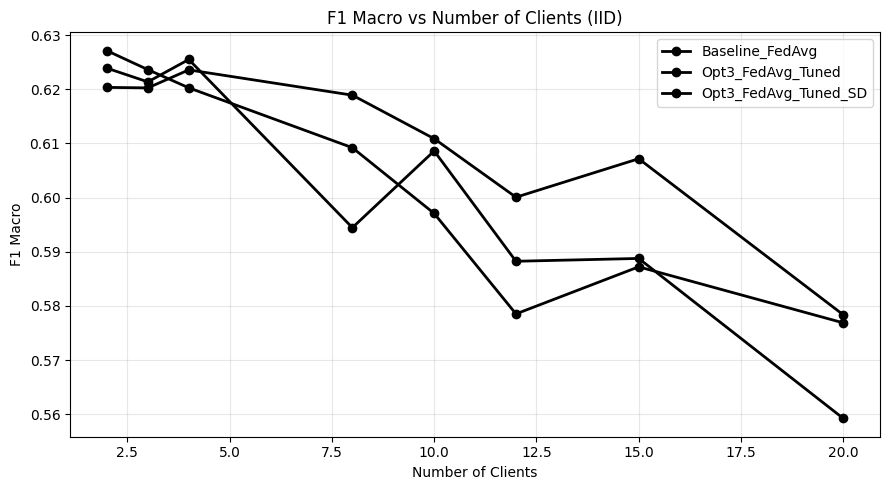

In [78]:
# Plot IID only

def plot_final_opt3_iid_metric(df, metric="f1_macro", bw=False):
    methods = [
        "Baseline_FedAvg",
        "Opt3_FedAvg_Tuned",
        "Opt3_FedAvg_Tuned_SD"
    ]

    plt.figure(figsize=(9, 5))

    for method in methods:
        g = df[df["method_name"] == method].sort_values("clients")

        if bw:
            plt.plot(
                g["clients"], g[metric],
                color="black",
                marker="o",
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g[metric],
                marker="o",
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients (IID)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_final_opt3_iid_metric(final_opt3_iid_df, metric="f1_macro", bw=False)
plot_final_opt3_iid_metric(final_opt3_iid_df, metric="pr_auc_macro", bw=False)
plot_final_opt3_iid_metric(final_opt3_iid_df, metric="f1_macro", bw=True)

In [79]:
# Combine IID + non-IID into a single CSV (while keeping originals)

final_opt3_noniid_out_path = os.path.join(KD_HISTORY_DIR, "final_opt3_noniid_sweep_r100_e3.csv")
final_opt3_iid_out_path    = os.path.join(KD_HISTORY_DIR, "final_opt3_iid_sweep_r100_e3.csv")

final_opt3_combined_path   = os.path.join(KD_HISTORY_DIR, "final_opt3_combined_sweep_r100_e3.csv")

# Load individual results
df_noniid = pd.read_csv(final_opt3_noniid_out_path)
df_iid    = pd.read_csv(final_opt3_iid_out_path)

# Combine
df_combined = pd.concat([df_iid, df_noniid], ignore_index=True)

# Save combined file
df_combined.to_csv(final_opt3_combined_path, index=False)

print(f"Saved combined results to: {final_opt3_combined_path}")

display(df_combined.head())

Saved combined results to: ../History/KD/final_opt3_combined_sweep_r100_e3.csv


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.594201,0.647317,0.902209,0.919055,0.629098,per-label,209.499002,NaN,NaN,NaN
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.596996,0.647961,0.902689,0.919226,0.636654,per-label,212.028694,NaN,NaN,NaN
2,iid,4,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.599839,0.651779,0.902924,0.920362,0.635661,per-label,212.538483,NaN,NaN,NaN
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.596664,0.654570,0.900414,0.919235,0.624013,per-label,217.224556,NaN,NaN,NaN
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,0.581805,0.638298,0.894814,0.915349,0.608158,per-label,220.758349,NaN,NaN,NaN
